In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Load the dataset
file_path = '/content/marylebone_train.csv'
df = pd.read_csv(file_path)

print('Original DataFrame Info:')
display(df.info())
display(df.head())

Original DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 42 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   date                        1000 non-null   object 
 1   year                        1000 non-null   int64  
 2   month                       1000 non-null   int64  
 3   day_of_month                1000 non-null   int64  
 4   day_of_week_x               1000 non-null   int64  
 5   day_of_year                 1000 non-null   int64  
 6   week_of_year                1000 non-null   int64  
 7   quarter                     1000 non-null   int64  
 8   is_weekend                  1000 non-null   int64  
 9   is_weekday                  1000 non-null   int64  
 10  season_code                 1000 non-null   int64  
 11  month_sin                   1000 non-null   float64
 12  month_cos                   1000 non-null   float64
 13  doy_sin  

None

,date,year,month,day_of_month,day_of_week_x,day_of_year,week_of_year,quarter,is_weekend,is_weekday,...,air_pressure_max_hpa,air_pressure_min_hpa,temperature_max_c,temperature_min_c,temperature_avg_c,mean_wind_speed_knots,wind_speed_max_knots,wind_speed_min_knots,wind_direction_deg,pm25
0,2022-04-07,2022,4,7,3,97,14,2,0,1,...,1000.9,983.9,13.59414,6.81972,10.206930,13.000000,16.0,4.0,270.636089,5.53
1,2022-04-08,2022,4,8,4,98,14,2,0,1,...,1008.6,997.8,11.35049,1.85771,6.604100,4.291667,9.0,1.0,16.779591,6.72
2,2022-04-09,2022,4,9,5,99,14,2,1,0,...,1019.1,1009.7,12.38106,0.59361,6.487335,5.458333,9.0,3.0,306.186614,5.62
3,2022-04-10,2022,4,10,6,100,14,2,1,0,...,1020.3,1016.2,13.33323,-0.20325,6.564990,2.916667,5.0,1.0,160.738319,8.36
4,2022-04-11,2022,4,11,0,101,15,2,0,1,...,1015.9,1005.9,17.46319,5.01811,11.240650,3.500000,7.0,1.0,119.167789,15.90


In [2]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

def calculate_metrics(y_true, y_pred):
    """
    Calculates and returns a dictionary of evaluation metrics.
    """
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    # MAPE: Avoid division by zero
    mape = np.where(
        y_true == 0,
        0,
        np.abs((y_true - y_pred) / y_true)
    ).mean() * 100

    # Mean Bias Error (MBE)
    mbe = np.mean(y_pred - y_true)

    return mae, rmse, r2, mape, mse, mbe

### Chronological Data Splitting
This is where the data is split into training, validation, and testing sets chronologically. This is crucial for time series data to ensure that the model is evaluated on future data it hasn't seen during training.

In [56]:
# Convert 'date' column to datetime objects (assuming 'date' is the time column)
# If your time column has a different name, please replace 'date' below.
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)
    print("Data sorted by 'date' column.")
else:
    print("Warning: 'date' column not found. Data might not be chronologically sorted. Assuming the data is already ordered.")

# Define split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# Calculate split indices
total_rows = len(df)
train_end_idx = int(total_rows * train_ratio)
val_end_idx = int(total_rows * (train_ratio + val_ratio))

# Split the dataframes
train_df = df.iloc[:train_end_idx]
val_df = df.iloc[train_end_idx:val_end_idx]
test_df = df.iloc[val_end_idx:]

print(f"Train set shape: {train_df.shape}")
print(f"Validation set shape: {val_df.shape}")
print(f"Test set shape: {test_df.shape}")

display(train_df.head())
display(val_df.head())
display(test_df.head())

Data sorted by 'date' column.
Train set shape: (700, 42)
Validation set shape: (150, 42)
Test set shape: (150, 42)


,date,year,month,day_of_month,day_of_week_x,day_of_year,week_of_year,quarter,is_weekend,is_weekday,...,air_pressure_max_hpa,air_pressure_min_hpa,temperature_max_c,temperature_min_c,temperature_avg_c,mean_wind_speed_knots,wind_speed_max_knots,wind_speed_min_knots,wind_direction_deg,pm25
0,2022-04-07,2022,4,7,3,97,14,2,0,1,...,1000.9,983.9,13.59414,6.81972,10.206930,13.000000,16.0,4.0,270.636089,5.53
1,2022-04-08,2022,4,8,4,98,14,2,0,1,...,1008.6,997.8,11.35049,1.85771,6.604100,4.291667,9.0,1.0,16.779591,6.72
2,2022-04-09,2022,4,9,5,99,14,2,1,0,...,1019.1,1009.7,12.38106,0.59361,6.487335,5.458333,9.0,3.0,306.186614,5.62
3,2022-04-10,2022,4,10,6,100,14,2,1,0,...,1020.3,1016.2,13.33323,-0.20325,6.564990,2.916667,5.0,1.0,160.738319,8.36
4,2022-04-11,2022,4,11,0,101,15,2,0,1,...,1015.9,1005.9,17.46319,5.01811,11.240650,3.500000,7.0,1.0,119.167789,15.90


,date,year,month,day_of_month,day_of_week_x,day_of_year,week_of_year,quarter,is_weekend,is_weekday,...,air_pressure_max_hpa,air_pressure_min_hpa,temperature_max_c,temperature_min_c,temperature_avg_c,mean_wind_speed_knots,wind_speed_max_knots,wind_speed_min_knots,wind_direction_deg,pm25
700,2024-03-07,2024,3,7,3,67,10,1,0,1,...,1023.9,1015.0,11.15655,3.56462,7.360585,3.125000,5.0,2.0,122.460465,30.5
701,2024-03-08,2024,3,8,4,68,10,1,0,1,...,1014.4,999.3,10.66239,4.52377,7.593080,3.416667,5.0,2.0,127.419038,26.6
702,2024-03-09,2024,3,9,5,69,10,1,1,0,...,998.5,992.2,13.45330,6.22943,9.841365,2.750000,4.0,2.0,120.416392,13.7
703,2024-03-10,2024,3,10,6,70,10,1,1,0,...,999.2,992.1,9.37640,7.75203,8.564215,1.791667,3.0,1.0,117.327449,15.0
704,2024-03-11,2024,3,11,0,71,11,1,0,1,...,1012.7,999.7,8.54206,7.14481,7.843435,4.958333,7.0,2.0,348.546681,32.3


,date,year,month,day_of_month,day_of_week_x,day_of_year,week_of_year,quarter,is_weekend,is_weekday,...,air_pressure_max_hpa,air_pressure_min_hpa,temperature_max_c,temperature_min_c,temperature_avg_c,mean_wind_speed_knots,wind_speed_max_knots,wind_speed_min_knots,wind_direction_deg,pm25
850,2024-08-04,2024,8,4,6,217,31,3,1,0,...,1016.6,1014.1,23.15112,11.72188,17.436500,4.750000,8.0,3.0,284.835795,6.2
851,2024-08-05,2024,8,5,0,218,32,3,0,1,...,1014.4,1010.7,25.49777,13.25496,19.376365,6.708333,9.0,4.0,238.004462,6.3
852,2024-08-06,2024,8,6,1,219,32,3,0,1,...,1011.3,1008.6,22.52387,16.70924,19.616555,4.708333,7.0,2.0,254.178375,6.6
853,2024-08-07,2024,8,7,2,220,32,3,0,1,...,1014.6,1011.3,22.00616,10.87152,16.438840,6.541667,11.0,2.0,251.657880,6.8
854,2024-08-08,2024,8,8,3,221,32,3,0,1,...,1015.7,1010.6,21.44164,12.21307,16.827355,6.500000,11.0,2.0,220.834231,6.2


### Feature Scaling

Feature scaling will be applied after splitting the data to prevent data leakage from the validation and test sets into the training process. A `MinMaxScaler` will be used and fitted only on the training data.

In [57]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Identify numerical columns for scaling
# Exclude non-numerical columns like 'date' if it's still present and not relevant for scaling
# If you have specific columns to exclude or include, adjust `numerical_cols`.

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'date' in numerical_cols: # Corrected from 'Date' to 'date'
    numerical_cols.remove('date')

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler ONLY on the training data
train_scaled = scaler.fit_transform(train_df[numerical_cols])

# Transform all datasets using the fitted scaler
val_scaled = scaler.transform(val_df[numerical_cols])
test_scaled = scaler.transform(test_df[numerical_cols])

# Convert scaled arrays back to DataFrames, preserving column names
train_scaled_df = pd.DataFrame(train_scaled, columns=numerical_cols, index=train_df.index)
val_scaled_df = pd.DataFrame(val_scaled, columns=numerical_cols, index=val_df.index)
test_scaled_df = pd.DataFrame(test_scaled, columns=numerical_cols, index=test_df.index)

print("Scaled Training Data (first 5 rows):")
display(train_scaled_df.head())
print("Scaled Validation Data (first 5 rows):")
display(val_scaled_df.head())
print("Scaled Test Data (first 5 rows):")
display(test_scaled_df.head())

Scaled Training Data (first 5 rows):


,year,month,day_of_month,day_of_week_x,day_of_year,week_of_year,quarter,is_weekend,is_weekday,season_code,...,air_pressure_max_hpa,air_pressure_min_hpa,temperature_max_c,temperature_min_c,temperature_avg_c,mean_wind_speed_knots,wind_speed_max_knots,wind_speed_min_knots,wind_direction_deg,pm25
0,0.0,0.272727,0.200000,0.500000,0.263736,0.254902,0.333333,0.0,1.0,0.333333,...,0.349070,0.339645,0.338240,0.519838,0.401473,0.862500,0.608696,0.333333,0.750836,0.093798
1,0.0,0.272727,0.233333,0.666667,0.266484,0.254902,0.333333,0.0,1.0,0.333333,...,0.459227,0.504142,0.280671,0.330425,0.288824,0.209375,0.304348,0.083333,0.039997,0.124548
2,0.0,0.272727,0.266667,0.833333,0.269231,0.254902,0.333333,1.0,0.0,0.333333,...,0.609442,0.644970,0.307114,0.282171,0.285173,0.296875,0.304348,0.250000,0.850383,0.096124
3,0.0,0.272727,0.300000,1.000000,0.271978,0.254902,0.333333,1.0,0.0,0.333333,...,0.626609,0.721893,0.331546,0.251753,0.287601,0.106250,0.130435,0.083333,0.443105,0.166925
4,0.0,0.272727,0.333333,0.000000,0.274725,0.274510,0.333333,0.0,1.0,0.333333,...,0.563662,0.600000,0.437514,0.451066,0.433794,0.150000,0.217391,0.083333,0.326700,0.361757


Scaled Validation Data (first 5 rows):


,year,month,day_of_month,day_of_week_x,day_of_year,week_of_year,quarter,is_weekend,is_weekday,season_code,...,air_pressure_max_hpa,air_pressure_min_hpa,temperature_max_c,temperature_min_c,temperature_avg_c,mean_wind_speed_knots,wind_speed_max_knots,wind_speed_min_knots,wind_direction_deg,pm25
700,1.0,0.181818,0.200000,0.500000,0.181319,0.176471,0.0,0.0,1.0,0.333333,...,0.678112,0.707692,0.275695,0.395582,0.312477,0.121875,0.130435,0.166667,0.335920,0.739018
701,1.0,0.181818,0.233333,0.666667,0.184066,0.176471,0.0,0.0,1.0,0.333333,...,0.542203,0.521893,0.263016,0.432196,0.319746,0.143750,0.130435,0.166667,0.349805,0.638243
702,1.0,0.181818,0.266667,0.833333,0.186813,0.176471,0.0,1.0,0.0,0.333333,...,0.314735,0.437870,0.334626,0.497305,0.390043,0.093750,0.086957,0.166667,0.330197,0.304910
703,1.0,0.181818,0.300000,1.000000,0.189560,0.176471,0.0,1.0,0.0,0.333333,...,0.324750,0.436686,0.230019,0.555427,0.350110,0.021875,0.043478,0.083333,0.321547,0.338501
704,1.0,0.181818,0.333333,0.000000,0.192308,0.196078,0.0,0.0,1.0,0.333333,...,0.517883,0.526627,0.208611,0.532247,0.327574,0.259375,0.217391,0.166667,0.968998,0.785530


Scaled Test Data (first 5 rows):


,year,month,day_of_month,day_of_week_x,day_of_year,week_of_year,quarter,is_weekend,is_weekday,season_code,...,air_pressure_max_hpa,air_pressure_min_hpa,temperature_max_c,temperature_min_c,temperature_avg_c,mean_wind_speed_knots,wind_speed_max_knots,wind_speed_min_knots,wind_direction_deg,pm25
850,1.0,0.636364,0.100000,1.000000,0.593407,0.588235,0.666667,1.0,0.0,0.666667,...,0.573677,0.697041,0.583458,0.706966,0.627518,0.243750,0.260870,0.250000,0.790597,0.111111
851,1.0,0.636364,0.133333,0.000000,0.596154,0.607843,0.666667,0.0,1.0,0.666667,...,0.542203,0.656805,0.643670,0.765488,0.688171,0.390625,0.304348,0.333333,0.659462,0.113695
852,1.0,0.636364,0.166667,0.166667,0.598901,0.607843,0.666667,0.0,1.0,0.666667,...,0.497854,0.631953,0.567364,0.897347,0.695681,0.240625,0.217391,0.166667,0.704752,0.121447
853,1.0,0.636364,0.200000,0.333333,0.601648,0.607843,0.666667,0.0,1.0,0.666667,...,0.545064,0.663905,0.554080,0.674506,0.596324,0.378125,0.391304,0.166667,0.697694,0.126615
854,1.0,0.636364,0.233333,0.500000,0.604396,0.607843,0.666667,0.0,1.0,0.666667,...,0.560801,0.655621,0.539596,0.725716,0.608472,0.375000,0.391304,0.166667,0.611383,0.111111


### Creating Time Windows (Look-back Sequences)

This step involves creating sequences of data points that can be used as input for recurrent neural networks or other sequence models. For a given `look_back_window`, each `X` sequence will contain `look_back_window` number of previous time steps, and `y` will be the value to predict at the next time step. You can adjust the `look_back_window` and `target_column` as needed.

In [5]:
def create_sequences(data, look_back_window, target_column=None):
    """
    Creates look-back sequences (X) and corresponding target values (y).

    Args:
        data (pd.DataFrame or np.ndarray): The input data (e.g., scaled training data).
        look_back_window (int): The number of previous time steps to include in each sequence.
        target_column (str, optional): The name of the column to predict. If None, the last column
                                     of the input data will be used as the target.

    Returns:
        tuple: A tuple containing:
            - X (np.ndarray): Array of sequences, shape (n_samples, look_back_window, n_features).
            - y (np.ndarray): Array of target values, shape (n_samples, 1).
    """
    X, y = [], []
    if isinstance(data, pd.DataFrame):
        # If target_column is not specified, use the last column for prediction.
        if target_column is None:
            target_idx = data.shape[1] - 1
            print(f"No target_column specified. Using the last column (index {target_idx}) for prediction.")
        else:
            if target_column not in data.columns:
                raise ValueError(f"Target column '{target_column}' not found in data.")
            target_idx = data.columns.get_loc(target_column)
        data_values = data.values
    else: # Assume numpy array
        if target_column is not None:
            raise ValueError("target_column can only be specified for pandas DataFrames.")
        target_idx = data.shape[1] - 1 # Use last column as target for numpy array
        data_values = data


    for i in range(len(data_values) - look_back_window):
        X.append(data_values[i:(i + look_back_window), :])
        y.append(data_values[i + look_back_window, target_idx])
    return np.array(X), np.array(y)

# --- Demonstration with a 7-day look-back window ---
look_back_window_7 = 7
# Example: Assuming the last column of your scaled data is the target to predict.
# If you have a specific target column (e.g., 'bookings'), specify it like:
# X_train_7, y_train_7 = create_sequences(train_scaled_df, look_back_window_7, target_column='your_target_column')
X_train_7, y_train_7 = create_sequences(train_scaled_df, look_back_window_7)
X_val_7, y_val_7 = create_sequences(val_scaled_df, look_back_window_7)
X_test_7, y_test_7 = create_sequences(test_scaled_df, look_back_window_7)

print(f"\n--- Sequences for {look_back_window_7}-day window ---")
print(f"X_train_7 shape: {X_train_7.shape}, y_train_7 shape: {y_train_7.shape}")
print(f"X_val_7 shape: {X_val_7.shape}, y_val_7 shape: {y_val_7.shape}")
print(f"X_test_7 shape: {X_test_7.shape}, y_test_7 shape: {y_test_7.shape}")

print("\nExample X_train_7[0]:")
print(X_train_7[0])
print("Example y_train_7[0]:")
print(y_train_7[0])

# You can repeat this for 14-day and 30-day windows as required:
# look_back_window_14 = 14
# X_train_14, y_train_14 = create_sequences(train_scaled_df, look_back_window_14)
# ... and so on for validation and test sets and a 30-day window.

No target_column specified. Using the last column (index 40) for prediction.
No target_column specified. Using the last column (index 40) for prediction.
No target_column specified. Using the last column (index 40) for prediction.

--- Sequences for 7-day window ---
X_train_7 shape: (693, 7, 41), y_train_7 shape: (693,)
X_val_7 shape: (143, 7, 41), y_val_7 shape: (143,)
X_test_7 shape: (143, 7, 41), y_test_7 shape: (143,)

Example X_train_7[0]:
[[0.00000000e+00 2.72727273e-01 2.00000000e-01 5.00000000e-01
  2.63736264e-01 2.54901961e-01 3.33333333e-01 0.00000000e+00
  1.00000000e+00 3.33333333e-01 9.33012702e-01 2.50000000e-01
  9.97557263e-01 4.50579755e-01 7.22520934e-01 5.55111512e-17
  9.96354437e-01 4.39731660e-01 7.92695413e-01 7.92695413e-01
  6.61264413e-01 8.34051054e-01 5.00000000e-01 3.33333333e-01
  4.17632450e-01 7.89592760e-01 2.58713137e-01 1.20879121e-01
  1.64179104e-01 0.00000000e+00 2.99748381e-01 3.49070100e-01
  3.39644970e-01 3.38240188e-01 5.19837919e-01 4.014725

In [6]:
# --- Create sequences for a 14-day look-back window ---
look_back_window_14 = 14
X_train_14, y_train_14 = create_sequences(train_scaled_df, look_back_window_14)
X_val_14, y_val_14 = create_sequences(val_scaled_df, look_back_window_14)
X_test_14, y_test_14 = create_sequences(test_scaled_df, look_back_window_14)

print(f"\n--- Sequences for {look_back_window_14}-day window ---")
print(f"X_train_14 shape: {X_train_14.shape}, y_train_14 shape: {y_train_14.shape}")
print(f"X_val_14 shape: {X_val_14.shape}, y_val_14 shape: {y_val_14.shape}")
print(f"X_test_14 shape: {X_test_14.shape}, y_test_14 shape: {y_test_14.shape}")

# --- Create sequences for a 30-day look-back window ---
look_back_window_30 = 30
X_train_30, y_train_30 = create_sequences(train_scaled_df, look_back_window_30)
X_val_30, y_val_30 = create_sequences(val_scaled_df, look_back_window_30)
X_test_30, y_test_30 = create_sequences(test_scaled_df, look_back_window_30)

print(f"\n--- Sequences for {look_back_window_30}-day window ---")
print(f"X_train_30 shape: {X_train_30.shape}, y_train_30 shape: {y_train_30.shape}")
print(f"X_val_30 shape: {X_val_30.shape}, y_val_30 shape: {y_val_30.shape}")
print(f"X_test_30 shape: {X_test_30.shape}, y_test_30 shape: {y_test_30.shape}")

No target_column specified. Using the last column (index 40) for prediction.
No target_column specified. Using the last column (index 40) for prediction.
No target_column specified. Using the last column (index 40) for prediction.

--- Sequences for 14-day window ---
X_train_14 shape: (686, 14, 41), y_train_14 shape: (686,)
X_val_14 shape: (136, 14, 41), y_val_14 shape: (136,)
X_test_14 shape: (136, 14, 41), y_test_14 shape: (136,)
No target_column specified. Using the last column (index 40) for prediction.
No target_column specified. Using the last column (index 40) for prediction.
No target_column specified. Using the last column (index 40) for prediction.

--- Sequences for 30-day window ---
X_train_30 shape: (670, 30, 41), y_train_30 shape: (670,)
X_val_30 shape: (120, 30, 41), y_val_30 shape: (120,)
X_test_30 shape: (120, 30, 41), y_test_30 shape: (120,)


### Why LSTM is Suitable for PM2.5 Forecasting

Long Short-Term Memory (LSTM) networks are a type of recurrent neural network (RNN) particularly well-suited for time series forecasting tasks like PM2.5 prediction due to their ability to learn long-term dependencies. Here's why:

1.  **Handles Sequential Data**: Environmental data like PM2.5 measurements are inherently sequential, where the value at a given time step is dependent on previous values. LSTMs are designed to process sequences of data by maintaining an internal state that captures information from earlier time steps.
2.  **Solves Vanishing/Exploding Gradient Problem**: Traditional RNNs suffer from the vanishing or exploding gradient problem, which makes it difficult to learn long-term dependencies. LSTMs overcome this with their unique gate mechanisms (input, forget, and output gates) that regulate the flow of information, allowing them to remember or forget information selectively over long sequences.
3.  **Captures Complex Patterns**: PM2.5 levels are influenced by various factors that evolve over time (e.g., weather conditions, seasonal changes, lagged pollution levels). LSTMs can model these complex, non-linear relationships and temporal dynamics effectively.
4.  **Memory Cells**: The core of an LSTM is its cell state, which acts as a memory unit. This cell state can carry relevant information across many time steps, enabling the network to learn which information to store and which to discard, making it ideal for forecasting based on historical data.

### LSTM Model Architecture

The proposed LSTM model architecture for PM2.5 forecasting will consist of the following layers:

1.  **Input Layer**: This layer receives the sequential input data. The `input_shape` will be `(look_back_window, n_features)`, where `look_back_window` is the length of the time sequence (e.g., 7, 14, or 30 days) and `n_features` is the number of features (columns) in your scaled dataset.
2.  **LSTM Layers**: One or two LSTM layers will be used to process the sequential input. Each LSTM layer contains memory cells and gating mechanisms to capture temporal dependencies. Using multiple layers can help the model learn hierarchical temporal features.
3.  **Dropout Layers**: Dropout layers are inserted after each LSTM layer (and potentially before the output layer) to prevent overfitting. Dropout randomly sets a fraction of input units to 0 at each update during training, which helps in regularization.
4.  **Dense Output Layer**: This is a fully connected layer with a single neuron (for a single-step forecast) that outputs the predicted PM2.5 value. Since PM2.5 is a continuous variable, no activation function (or a linear activation) is typically used for regression tasks.

In [52]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

# Assuming we use the 7-day look-back window for this model definition
# You can change `look_back_window` to 14 or 30 for different models
look_back_window = look_back_window_7 # Using the 7-day window for this example
n_features = X_train_7.shape[2] # Number of features is the last dimension of X_train

print(f"Defining LSTM model with input shape: ({look_back_window}, {n_features})")

# Build the LSTM model
model = Sequential()
model.add(Input(shape=(look_back_window, n_features))) # Explicit Input layer
model.add(LSTM(units=50, return_sequences=True)) # First LSTM layer, returns sequences for the next LSTM layer
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False)) # Second LSTM layer, does not return sequences for the Dense layer
model.add(Dropout(0.2))
model.add(Dense(units=1)) # Output layer for single-step prediction

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Display model summary
model.summary()

Defining LSTM model with input shape: (7, 41)


Model: "sequential_61"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_60 (LSTM)                  │ (None, 7, 50)          │        18,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_122 (Dropout)           │ (None, 7, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_61 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_123 (Dropout)           │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,651 (150.98 KB)

 Trainable params: 38,651 (150.98 KB)

 Non-trainable params: 0 (0.00 B)

### Model Training Parameters

To effectively train the LSTM model, we need to define key parameters:

*   **Batch Size**: The number of samples processed before the model's internal parameters are updated. A common choice is 32 or 64.
*   **Epochs**: The number of complete passes through the entire training dataset. Too few epochs can lead to underfitting, while too many can lead to overfitting.
*   **Early Stopping**: A crucial technique to prevent overfitting. It monitors a chosen metric (e.g., validation loss) and stops training if the metric stops improving for a specified number of epochs (patience). This saves computation time and helps in finding the optimal point where the model generalizes best to unseen data.

In [8]:
# Define training parameters
batch_size = 32
epochs = 100 # Set a reasonably high number, early stopping will prevent overfitting

# Implement Early Stopping
# Monitors 'val_loss' and stops if it doesn't improve for 'patience' epochs
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True # Restores model weights from the epoch with the best value of the monitored metric.
)

print(f"Training the model with batch_size={batch_size} and epochs={epochs}.")
print(f"Early stopping configured with patience={early_stopping.patience} on '{early_stopping.monitor}'.")

# Train the model
# Using X_train_7, y_train_7, X_val_7, y_val_7 for the 7-day look-back window
history = model.fit(
    X_train_7,
    y_train_7,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val_7, y_val_7),
    callbacks=[early_stopping],
    verbose=1 # Display training progress
)

print("\nModel training complete.")

Training the model with batch_size=32 and epochs=100.
Early stopping configured with patience=10 on 'val_loss'.
Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0197 - val_loss: 0.0068
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0158 - val_loss: 0.0097
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0153 - val_loss: 0.0067
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0152 - val_loss: 0.0073
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0160 - val_loss: 0.0080
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0137 - val_loss: 0.0060
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0133 - val_loss: 0.0060
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0130 - val_loss: 0.0060
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0141 - val_loss: 0.0069
Epoch 10/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0127 - val_loss: 0.0057
Epoch 11/100
22/22 ━━━━━━━━

### Model Summary and Architecture Diagram

Below is the summary of the model's architecture, including the layers, output shapes, and the number of parameters. This helps in understanding the complexity and structure of the network.

To visualize the model's architecture graphically, you can use `tf.keras.utils.plot_model`. This function will create an image file representing the model's graph. For this to work, you might need to install `graphviz` and `pydot`.

In [9]:
 model.summary()


try:
    tf.keras.utils.plot_model(model, to_file='lstm_model_architecture.png', show_shapes=True, show_layer_names=True)
    print("\nModel architecture plot saved to 'lstm_model_architecture.png'.")
except ImportError:
    print("\nCould not generate model architecture plot. Please install 'pydot' and 'graphviz' if you wish to see it visually:")
    print("pip install pydot graphviz")
except Exception as e:
    print(f"\nAn error occurred while plotting the model: {e}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 50)          │        18,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,955 (452.95 KB)

 Trainable params: 38,651 (150.98 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 77,304 (301.97 KB)


Model architecture plot saved to 'lstm_model_architecture.png'.


## Build the GRU Model

Now, we will build a Gated Recurrent Unit (GRU) model, similar in structure to the LSTM model. GRU networks are another type of recurrent neural network that can capture temporal dependencies in sequential data, often with fewer parameters than LSTMs, leading to potentially faster training.

In [53]:
from tensorflow.keras.layers import GRU, Input

# Reuse look_back_window and n_features from the LSTM model definition
# look_back_window = look_back_window_7 # Already defined as 7
# n_features = X_train_7.shape[2] # Already defined as 41

print(f"Defining GRU model with input shape: ({look_back_window}, {n_features})")

# Build the GRU model
gru_model = Sequential()
gru_model.add(Input(shape=(look_back_window, n_features))) # Explicit Input layer
gru_model.add(GRU(units=50, return_sequences=True)) # First GRU layer
gru_model.add(Dropout(0.2))
gru_model.add(GRU(units=50, return_sequences=False)) # Second GRU layer
gru_model.add(Dropout(0.2))
gru_model.add(Dense(units=1)) # Output layer for single-step prediction

# Compile the GRU model (using the same optimizer and loss function as LSTM)
gru_model.compile(optimizer='adam', loss='mean_squared_error')

Defining GRU model with input shape: (7, 41)


### GRU Model Training Parameters

Similar to the LSTM model, we will use the same training parameters including batch size, epochs, and early stopping to train the GRU model. This ensures a fair comparison between the two architectures.

In [11]:
# Reuse training parameters from the LSTM model
# batch_size = 32 # Already defined
# epochs = 100 # Already defined
# early_stopping # Already defined

print(f"Training the GRU model with batch_size={batch_size} and epochs={epochs}.")
print(f"Early stopping configured with patience={early_stopping.patience} on '{early_stopping.monitor}'.")

# Train the GRU model
history_gru = gru_model.fit(
    X_train_7,
    y_train_7,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val_7, y_val_7),
    callbacks=[early_stopping],
    verbose=1 # Display training progress
)

print("\nGRU Model training complete.")

Training the GRU model with batch_size=32 and epochs=100.
Early stopping configured with patience=10 on 'val_loss'.
Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - loss: 0.0592 - val_loss: 0.0137
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0270 - val_loss: 0.0092
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0228 - val_loss: 0.0075
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0193 - val_loss: 0.0067
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0174 - val_loss: 0.0064
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0171 - val_loss: 0.0060
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0152 - val_loss: 0.0061
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0148 - val_loss: 0.0061
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0145 - val_loss: 0.0073
Epoch 10/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0147 - val_loss: 0.0063

GRU Model training com

### GRU Model Summary and Architecture Diagram

Below is the summary of the GRU model's architecture, showing its layers, output shapes, and the number of parameters. We'll also attempt to visualize its architecture.

In [12]:
# Display GRU model summary
gru_model.summary()

# Optional: Generate and display a plot of the GRU model architecture
try:
    tf.keras.utils.plot_model(gru_model, to_file='gru_model_architecture.png', show_shapes=True, show_layer_names=True)
    print("\nGRU model architecture plot saved to 'gru_model_architecture.png'.")
except ImportError:
    print("\nCould not generate GRU model architecture plot. Please install 'pydot' and 'graphviz' if you wish to see it visually:")
    print("pip install pydot graphviz")
except Exception as e:
    print(f"\nAn error occurred while plotting the GRU model: {e}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 7, 50)          │        13,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,905 (343.38 KB)

 Trainable params: 29,301 (114.46 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 58,604 (228.93 KB)


GRU model architecture plot saved to 'gru_model_architecture.png'.


## Train Models for All Forecast Horizons

As per the document, we need to train both LSTM and GRU models for three different forecast horizons: 7-day, 14-day, and 30-day predictions. We have already trained the models for the 7-day prediction. Now, we will proceed to train the models for the 14-day and 30-day forecast horizons.

### LSTM Model for 14-day Prediction

In [54]:
print(f"Defining LSTM model for 14-day prediction with input shape: ({look_back_window_14}, {n_features})")

# Build the LSTM model for 14-day prediction
lstm_model_14 = Sequential()
lstm_model_14.add(Input(shape=(look_back_window_14, n_features))) # Explicit Input layer
lstm_model_14.add(LSTM(units=50, return_sequences=True))
lstm_model_14.add(Dropout(0.2))
lstm_model_14.add(LSTM(units=50, return_sequences=False))
lstm_model_14.add(Dropout(0.2))
lstm_model_14.add(Dense(units=1))

# Compile the model
lstm_model_14.compile(optimizer='adam', loss='mean_squared_error')

# Display model summary
lstm_model_14.summary()

print(f"\nTraining the 14-day LSTM model with batch_size={batch_size} and epochs={epochs}.")
print(f"Early stopping configured with patience={early_stopping.patience} on '{early_stopping.monitor}'.")

# Train the model
history_lstm_14 = lstm_model_14.fit(
    X_train_14,
    y_train_14,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val_14, y_val_14),
    callbacks=[early_stopping],
    verbose=1 # Display training progress
)

print("\nLSTM 14-day Model training complete.")

Defining LSTM model for 14-day prediction with input shape: (14, 41)


Model: "sequential_63"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_62 (LSTM)                  │ (None, 14, 50)         │        18,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_126 (Dropout)           │ (None, 14, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_63 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_127 (Dropout)           │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,651 (150.98 KB)

 Trainable params: 38,651 (150.98 KB)

 Non-trainable params: 0 (0.00 B)


Training the 14-day LSTM model with batch_size=64 and epochs=100.
Early stopping configured with patience=10 on 'val_loss'.
Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - loss: 0.0309 - val_loss: 0.0175
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0200 - val_loss: 0.0063
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0182 - val_loss: 0.0062
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0156 - val_loss: 0.0068
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0140 - val_loss: 0.0061
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0147 - val_loss: 0.0063
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0143 - val_loss: 0.0068
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0140 - val_loss: 0.0067
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0141 - val_loss: 0.0065
Epoch 10/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0145 - val_loss: 0.0072

LSTM 14-day M

### LSTM Model for 30-day Prediction

In [55]:
print(f"Defining LSTM model for 30-day prediction with input shape: ({look_back_window_30}, {n_features})")

# Build the LSTM model for 30-day prediction
lstm_model_30 = Sequential()
lstm_model_30.add(Input(shape=(look_back_window_30, n_features))) # Explicit Input layer
lstm_model_30.add(LSTM(units=50, return_sequences=True))
lstm_model_30.add(Dropout(0.2))
lstm_model_30.add(LSTM(units=50, return_sequences=False))
lstm_model_30.add(Dropout(0.2))
lstm_model_30.add(Dense(units=1))

# Compile the model
lstm_model_30.compile(optimizer='adam', loss='mean_squared_error')

# Display model summary
lstm_model_30.summary()

print(f"\nTraining the 30-day LSTM model with batch_size={batch_size} and epochs={epochs}.")
print(f"Early stopping configured with patience={early_stopping.patience} on '{early_stopping.monitor}'.")

# Train the model
history_lstm_30 = lstm_model_30.fit(
    X_train_30,
    y_train_30,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val_30, y_val_30),
    callbacks=[early_stopping],
    verbose=1 # Display training progress
)

print("\nLSTM 30-day Model training complete.")

Defining LSTM model for 30-day prediction with input shape: (30, 41)


Model: "sequential_64"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_64 (LSTM)                  │ (None, 30, 50)         │        18,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_128 (Dropout)           │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_65 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_129 (Dropout)           │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,651 (150.98 KB)

 Trainable params: 38,651 (150.98 KB)

 Non-trainable params: 0 (0.00 B)


Training the 30-day LSTM model with batch_size=64 and epochs=100.
Early stopping configured with patience=10 on 'val_loss'.
Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0332 - val_loss: 0.0072
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0229 - val_loss: 0.0058
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0181 - val_loss: 0.0056
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0169 - val_loss: 0.0067
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0164 - val_loss: 0.0067
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0148 - val_loss: 0.0065
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0155 - val_loss: 0.0057
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0147 - val_loss: 0.0056
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0140 - val_loss: 0.0066
Epoch 10/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 0.0144 - val_loss: 0.0059

LSTM 30-day M

### GRU Model for 14-day Prediction

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ============================================================
# 14-DAY GRU MODEL
# ============================================================

print(
    f"Defining GRU model for 14-day prediction "
    f"with input shape: ({look_back_window_14}, {n_features})"
)

# ------------------------------------------------------------
# Hyperparameters
# ------------------------------------------------------------

gru_units_14 = 50
gru_dropout_14 = 0.2
batch_size_14 = 64
epochs_14 = 100
patience_14 = 10

# ------------------------------------------------------------
# Build the GRU model
# ------------------------------------------------------------

gru_model_14 = Sequential([

    Input(shape=(look_back_window_14, n_features)),

    GRU(
        units=gru_units_14,
        return_sequences=True
    ),

    Dropout(gru_dropout_14),

    GRU(
        units=gru_units_14,
        return_sequences=False
    ),

    Dropout(gru_dropout_14),

    Dense(1)
])

# ------------------------------------------------------------
# Compile the model
# ------------------------------------------------------------

gru_model_14.compile(
    optimizer="adam",
    loss="mse"
)

# ------------------------------------------------------------
# Display model summary
# ------------------------------------------------------------

gru_model_14.summary()

# ------------------------------------------------------------
# Early stopping
# ------------------------------------------------------------

early_stopping_14 = EarlyStopping(
    monitor="val_loss",
    patience=patience_14,
    restore_best_weights=True
)

print(
    f"\nTraining the 14-day GRU model "
    f"with batch_size={batch_size_14} "
    f"and maximum epochs={epochs_14}."
)

print(
    f"Early stopping: patience={patience_14}, "
    f"monitor='val_loss'"
)

# ------------------------------------------------------------
# Train the model
# ------------------------------------------------------------

history_gru_14 = gru_model_14.fit(

    X_train_14,
    y_train_14,

    epochs=epochs_14,
    batch_size=batch_size_14,

    validation_data=(
        X_val_14,
        y_val_14
    ),

    callbacks=[early_stopping_14],

    verbose=1
)

print("\nGRU 14-day model training complete.")

print(
    f"Epochs actually completed: "
    f"{len(history_gru_14.history['loss'])}"
)

# ============================================================
# EVALUATE 14-DAY GRU MODEL
# ============================================================

print("\nEvaluating the 14-day GRU model...")

y_pred_gru_14 = gru_model_14.predict(
    X_test_14,
    verbose=0
).flatten()

# Calculate all six metrics
mae_14, rmse_14, r2_14, mape_14, mse_14, mbe_14 = calculate_metrics(
    y_test_14,
    y_pred_gru_14
)

print("\n" + "=" * 55)
print("GRU 14-DAY TEST RESULTS")
print("=" * 55)

print(f"MAE  : {mae_14:.4f}")
print(f"RMSE : {rmse_14:.4f}")
print(f"R²   : {r2_14:.4f}")
print(f"MAPE : {mape_14:.2f}%")
print(f"MSE  : {mse_14:.4f}")
print(f"MBE  : {mbe_14:.4f}")

print("=" * 55)

Defining GRU model for 14-day prediction with input shape: (14, 41)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 14, 50)         │        13,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 14, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,301 (114.46 KB)

 Trainable params: 29,301 (114.46 KB)

 Non-trainable params: 0 (0.00 B)


Training the 14-day GRU model with batch_size=64 and maximum epochs=100.
Early stopping: patience=10, monitor='val_loss'
Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - loss: 0.1016 - val_loss: 0.0076
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0499 - val_loss: 0.0245
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0304 - val_loss: 0.0072
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0302 - val_loss: 0.0052
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0247 - val_loss: 0.0075
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0220 - val_loss: 0.0049
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0206 - val_loss: 0.0048
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0189 - val_loss: 0.0064
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0176 - val_loss: 0.0047
Epoch 10/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0178 - val_loss: 0.0054
Epoch 11/100
11/1



```
# This is formatted as code
```

### GRU Model for 30-day Prediction

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ============================================================
# 30-DAY GRU MODEL
# ============================================================

print(
    f"Defining GRU model for 30-day prediction "
    f"with input shape: ({look_back_window_30}, {n_features})"
)

# ------------------------------------------------------------
# Hyperparameters
# ------------------------------------------------------------

gru_units_30 = 50
gru_dropout_30 = 0.2
batch_size_30 = 64
epochs_30 = 100
patience_30 = 10

# ------------------------------------------------------------
# Build the GRU model
# ------------------------------------------------------------

gru_model_30 = Sequential([

    Input(shape=(look_back_window_30, n_features)),

    GRU(
        units=gru_units_30,
        return_sequences=True
    ),

    Dropout(gru_dropout_30),

    GRU(
        units=gru_units_30,
        return_sequences=False
    ),

    Dropout(gru_dropout_30),

    Dense(1)
])

# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

gru_model_30.compile(
    optimizer="adam",
    loss="mse"
)

# ------------------------------------------------------------
# Display model architecture
# ------------------------------------------------------------

gru_model_30.summary()

# ------------------------------------------------------------
# Early stopping
# ------------------------------------------------------------

early_stopping_30 = EarlyStopping(
    monitor="val_loss",
    patience=patience_30,
    restore_best_weights=True
)

print(
    f"\nTraining the 30-day GRU model "
    f"with batch_size={batch_size_30} "
    f"and maximum epochs={epochs_30}."
)

print(
    f"Early stopping: patience={patience_30}, "
    f"monitor='val_loss'"
)

# ------------------------------------------------------------
# Train the model
# ------------------------------------------------------------

history_gru_30 = gru_model_30.fit(

    X_train_30,
    y_train_30,

    epochs=epochs_30,
    batch_size=batch_size_30,

    validation_data=(
        X_val_30,
        y_val_30
    ),

    callbacks=[early_stopping_30],

    verbose=1
)

print("\nGRU 30-day model training complete.")

print(
    f"Epochs actually completed: "
    f"{len(history_gru_30.history['loss'])}"
)

# ============================================================
# EVALUATE 30-DAY GRU
# ============================================================

print("\nEvaluating the 30-day GRU model...")

y_pred_gru_30 = gru_model_30.predict(
    X_test_30,
    verbose=0
).flatten()

# Calculate metrics
mae_30, rmse_30, r2_30, mape_30, mse_30, mbe_30 = calculate_metrics(
    y_test_30,
    y_pred_gru_30
)

print("\n" + "=" * 55)
print("GRU 30-DAY TEST RESULTS")
print("=" * 55)

print(f"MAE  : {mae_30:.4f}")
print(f"RMSE : {rmse_30:.4f}")
print(f"R²   : {r2_30:.4f}")
print(f"MAPE : {mape_30:.2f}%")
print(f"MSE  : {mse_30:.4f}")
print(f"MBE  : {mbe_30:.4f}")

print("=" * 55)

Defining GRU model for 30-day prediction with input shape: (30, 41)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_4 (GRU)                     │ (None, 30, 50)         │        13,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,301 (114.46 KB)

 Trainable params: 29,301 (114.46 KB)

 Non-trainable params: 0 (0.00 B)


Training the 30-day GRU model with batch_size=64 and maximum epochs=100.
Early stopping: patience=10, monitor='val_loss'
Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - loss: 0.0680 - val_loss: 0.0090
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0419 - val_loss: 0.0096
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0299 - val_loss: 0.0073
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0249 - val_loss: 0.0061
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0198 - val_loss: 0.0057
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0197 - val_loss: 0.0062
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0185 - val_loss: 0.0071
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0177 - val_loss: 0.0057
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0161 - val_loss: 0.0057
Epoch 10/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0158 - val_loss: 0.0061
Epoch 11/100
11/1


```
 ```

### GRU Model for 7-day Prediction

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ============================================================
# 7-DAY GRU MODEL
# ============================================================

print(
    f"Defining GRU model for 7-day prediction "
    f"with input shape: ({look_back_window_7}, {n_features})"
)

# ------------------------------------------------------------
# Hyperparameters
# ------------------------------------------------------------

gru_units_7 = 50
gru_dropout_7 = 0.2
batch_size_7 = 64
epochs_7 = 100
patience_7 = 10

# ------------------------------------------------------------
# Build the GRU model
# ------------------------------------------------------------

gru_model_7 = Sequential([

    Input(shape=(look_back_window_7, n_features)),

    GRU(
        units=gru_units_7,
        return_sequences=True
    ),

    Dropout(gru_dropout_7),

    GRU(
        units=gru_units_7,
        return_sequences=False
    ),

    Dropout(gru_dropout_7),

    Dense(1)
])

# ------------------------------------------------------------
# Compile the model
# ------------------------------------------------------------

gru_model_7.compile(
    optimizer="adam",
    loss="mse"
)

# ------------------------------------------------------------
# Display model summary
# ------------------------------------------------------------

gru_model_7.summary()

# ------------------------------------------------------------
# Early stopping
# ------------------------------------------------------------

early_stopping_7 = EarlyStopping(
    monitor="val_loss",
    patience=patience_7,
    restore_best_weights=True
)

print(
    f"\nTraining the 7-day GRU model "
    f"with batch_size={batch_size_7} "
    f"and maximum epochs={epochs_7}."
)

print(
    f"Early stopping: patience={patience_7}, "
    f"monitor='val_loss'"
)

# ------------------------------------------------------------
# Train the model
# ------------------------------------------------------------

history_gru_7 = gru_model_7.fit(

    X_train_7,
    y_train_7,

    epochs=epochs_7,
    batch_size=batch_size_7,

    validation_data=(
        X_val_7,
        y_val_7
    ),

    callbacks=[early_stopping_7],

    verbose=1
)

print("\nGRU 7-day model training complete.")

print(
    f"Epochs actually completed: "
    f"{len(history_gru_7.history['loss'])}"
)

# ============================================================
# EVALUATE 7-DAY GRU MODEL
# ============================================================

print("\nEvaluating the 7-day GRU model...")

y_pred_gru_7 = gru_model_7.predict(
    X_test_7,
    verbose=0
).flatten()

# Calculate all six metrics
mae_7, rmse_7, r2_7, mape_7, mse_7, mbe_7 = calculate_metrics(
    y_test_7,
    y_pred_gru_7
)

print("\n" + "=" * 55)
print("GRU 7-DAY TEST RESULTS")
print("=" * 55)

print(f"MAE  : {mae_7:.4f}")
print(f"RMSE : {rmse_7:.4f}")
print(f"R²   : {r2_7:.4f}")
print(f"MAPE : {mape_7:.2f}%")
print(f"MSE  : {mse_7:.4f}")
print(f"MBE  : {mbe_7:.4f}")

print("=" * 55)

Defining GRU model for 7-day prediction with input shape: (7, 41)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_6 (GRU)                     │ (None, 7, 50)          │        13,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 7, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_7 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,301 (114.46 KB)

 Trainable params: 29,301 (114.46 KB)

 Non-trainable params: 0 (0.00 B)


Training the 7-day GRU model with batch_size=64 and maximum epochs=100.
Early stopping: patience=10, monitor='val_loss'
Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - loss: 0.0703 - val_loss: 0.0154
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0367 - val_loss: 0.0071
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0251 - val_loss: 0.0062
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0220 - val_loss: 0.0062
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0191 - val_loss: 0.0074
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0199 - val_loss: 0.0064
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0192 - val_loss: 0.0058
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0171 - val_loss: 0.0057
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0169 - val_loss: 0.0058
Epoch 10/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0151 - val_loss: 0.0063
Epoch 11/100
11/11


GRU 7-DAY TEST RESULTS
MAE  : 0.0778
RMSE : 0.1063
R²   : 0.3637
MAPE : 63.15%
MSE  : 0.0113
MBE  : -0.0206


## Hyperparameter Tuning

  This section explains the rationale behind the chosen configuration for our LSTM and GRU models, covering key parameters that influence their training and effectiveness.

### Basic Hyperparameter Tuning for LSTM 7-Day Model

To demonstrate hyperparameter tuning, we will perform a basic search for the LSTM 7-Day model, which showed the best performance among the initial runs. We will explore variations in `units`, `dropout_rate`, and `batch_size` to see if we can further improve its performance. Given computational constraints, this will be a limited search, but it demonstrates the process.

This basic hyperparameter tuning process provides an overview of how to systematically search for better model configurations. The best-performing combination from this limited search is highlighted. For a more robust tuning process, consider using libraries like Keras Tuner or Optuna, which offer more sophisticated search algorithms and better management of tuning experiments.

### Hyperparameter Tuning for GRU 7-Day Model

This section details the hyperparameter tuning process for the GRU (Gated Recurrent Unit) model, specifically focusing on the 7-day forecast horizon. We aim to identify the optimal combination of `units`, `dropout_rate`, and `batch_size` to maximize the model's performance on unseen data, as measured by various evaluation metrics, particularly R².

### Detailed GRU Hyperparameter Tuning Process

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

def calculate_metrics(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    # Avoid division by zero for MAPE
    mape = np.where(
        y_true == 0,
        0,
        np.abs((y_true - y_pred) / y_true)
    ).mean() * 100

    mbe = np.mean(y_pred - y_true)

    return mae, rmse, r2, mape, mse, mbe


# Hyperparameter Search Space for GRU
hyperparameters_gru = {
    "units": [32, 50, 64],
    "dropout_rate": [0.1, 0.2, 0.3],
    "batch_size": [16, 32, 64]
}

epochs = 100
patience = 10

look_back_window = look_back_window_7 # Using the 7-day window
n_features = X_train_7.shape[2]

gru_results = []

best_gru_model = None
best_gru_r2 = -999

print("="*60)
print("Starting GRU Hyperparameter Tuning")
print("="*60)

for units in hyperparameters_gru["units"]:

    for dropout_rate in hyperparameters_gru["dropout_rate"]:

        for batch_size in hyperparameters_gru["batch_size"]:

            print(f"\nGRU: Units={units} | Dropout={dropout_rate} | Batch={batch_size}")

            # Build Model
            gru_model_tuned = Sequential([
                Input(shape=(look_back_window, n_features)),
                GRU(units, return_sequences=True),
                Dropout(dropout_rate),
                GRU(units),
                Dropout(dropout_rate),
                Dense(1)
            ])

            gru_model_tuned.compile(
                optimizer="adam",
                loss="mse"
            )

            early_stop = EarlyStopping(
                monitor="val_loss",
                patience=patience,
                restore_best_weights=True
            )

            history = gru_model_tuned.fit(
                X_train_7,
                y_train_7,
                validation_data=(X_val_7, y_val_7),
                epochs=epochs,
                batch_size=batch_size,
                callbacks=[early_stop],
                verbose=0
            )

            # Predictions
            predictions = gru_model_tuned.predict(
                X_test_7,
                verbose=0
            ).flatten()

            mae, rmse, r2, mape, mse, mbe = calculate_metrics(
                y_test_7,
                predictions
            )

            gru_results.append({
                "Model": "GRU",
                "Horizon": "7 Day",
                "Units": units,
                "Dropout": dropout_rate,
                "Batch Size": batch_size,
                "Epochs Used": len(history.history["loss"]),
                "MAE": mae,
                "RMSE": rmse,
                "R²": r2,
                "MAPE": mape,
                "MSE": mse,
                "MBE": mbe
            })

            print(
                f"R²={r2:.4f} | "
                f"RMSE={rmse:.4f} | "
                f"MAE={mae:.4f}"
            )

            if r2 > best_gru_r2:
                best_gru_r2 = r2
                best_gru_model = gru_model_tuned

# Results Table for GRU
gru_results_df = pd.DataFrame(gru_results)

gru_results_df = gru_results_df.sort_values(
    by="R²",
    ascending=False
).reset_index(drop=True)

print("\n")
print("="*70)
print("TOP 10 GRU HYPERPARAMETER CONFIGURATIONS (7-Day)")
print("="*70)

display(gru_results_df.head(10))

print("\n")
print("="*70)
print("BEST GRU CONFIGURATION (7-Day)")
print("="*70)

display(gru_results_df.iloc[[0]])

# Save the best GRU model
if best_gru_model:
    best_gru_model.save("Best_GRU_Model_7Day.keras")
    print("\nBest GRU model (7-Day) saved as:")
    print("Best_GRU_Model_7Day.keras")

Starting GRU Hyperparameter Tuning

GRU: Units=32 | Dropout=0.1 | Batch=16
R²=0.4073 | RMSE=0.1026 | MAE=0.0696

GRU: Units=32 | Dropout=0.1 | Batch=32
R²=0.3888 | RMSE=0.1042 | MAE=0.0766

GRU: Units=32 | Dropout=0.1 | Batch=64
R²=0.2975 | RMSE=0.1117 | MAE=0.0817

GRU: Units=32 | Dropout=0.2 | Batch=16
R²=0.3520 | RMSE=0.1073 | MAE=0.0782

GRU: Units=32 | Dropout=0.2 | Batch=32
R²=0.3653 | RMSE=0.1062 | MAE=0.0766

GRU: Units=32 | Dropout=0.2 | Batch=64
R²=0.3320 | RMSE=0.1090 | MAE=0.0799

GRU: Units=32 | Dropout=0.3 | Batch=16
R²=0.4602 | RMSE=0.0979 | MAE=0.0725

GRU: Units=32 | Dropout=0.3 | Batch=32
R²=0.4005 | RMSE=0.1032 | MAE=0.0759

GRU: Units=32 | Dropout=0.3 | Batch=64
R²=0.2752 | RMSE=0.1135 | MAE=0.0840

GRU: Units=50 | Dropout=0.1 | Batch=16
R²=0.4279 | RMSE=0.1008 | MAE=0.0751

GRU: Units=50 | Dropout=0.1 | Batch=32
R²=0.3509 | RMSE=0.1074 | MAE=0.0799

GRU: Units=50 | Dropout=0.1 | Batch=64
R²=0.3620 | RMSE=0.1065 | MAE=0.0764

GRU: Units=50 | Dropout=0.2 | Batch=16
R

,Model,Horizon,Units,Dropout,Batch Size,Epochs Used,MAE,RMSE,R²,MAPE,MSE,MBE
0,GRU,7 Day,32,0.3,16,73,0.072495,0.097946,0.460242,64.120840,0.009594,-0.003536
1,GRU,7 Day,50,0.1,16,33,0.075094,0.100835,0.427937,64.791458,0.010168,-0.002684
2,GRU,7 Day,64,0.1,16,36,0.074556,0.101007,0.425981,60.237335,0.010202,-0.009455
3,GRU,7 Day,64,0.1,64,50,0.075688,0.102289,0.411321,64.034414,0.010463,-0.005687
4,GRU,7 Day,64,0.1,32,48,0.074311,0.102295,0.411247,62.666047,0.010464,-0.016681
5,GRU,7 Day,32,0.1,16,88,0.069625,0.102640,0.407268,61.702150,0.010535,-0.021487
6,GRU,7 Day,50,0.2,32,71,0.076027,0.103112,0.401807,63.945183,0.010632,-0.010187
7,GRU,7 Day,32,0.3,32,78,0.075886,0.103223,0.400524,67.717001,0.010655,-0.007490
8,GRU,7 Day,64,0.3,64,71,0.075801,0.103750,0.394383,63.737884,0.010764,-0.011950
9,GRU,7 Day,64,0.2,64,63,0.075322,0.103815,0.393628,61.444093,0.010777,-0.017178




BEST GRU CONFIGURATION (7-Day)


,Model,Horizon,Units,Dropout,Batch Size,Epochs Used,MAE,RMSE,R²,MAPE,MSE,MBE
0,GRU,7 Day,32,0.3,16,73,0.072495,0.097946,0.460242,64.12084,0.009594,-0.003536



Best GRU model (7-Day) saved as:
Best_GRU_Model_7Day.keras


### Hyperparameter Tuning for LSTM 7-Day Model

This section outlines the hyperparameter tuning process for the LSTM (Long Short-Term Memory) model, with a focus on the 7-day forecast horizon. The objective is to discover the best configuration of `units`, `dropout_rate`, and `batch_size` that leads to the highest predictive accuracy and generalization capability for the LSTM model.

### Detailed LSTM Hyperparameter Tuning Process

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# The calculate_metrics function is already defined in a previous cell.

# Hyperparameter Search Space for LSTM
hyperparameters_lstm = {
    "units": [32, 50, 64],
    "dropout_rate": [0.1, 0.2, 0.3],
    "batch_size": [16, 32, 64]
}

epochs = 100
patience = 10

look_back_window = look_back_window_7 # Using the 7-day window
n_features = X_train_7.shape[2]

lstm_results = []

best_lstm_model = None
best_lstm_r2 = -999

print("="*60)
print("Starting LSTM Hyperparameter Tuning")
print("="*60)

for units in hyperparameters_lstm["units"]:

    for dropout_rate in hyperparameters_lstm["dropout_rate"]:

        for batch_size in hyperparameters_lstm["batch_size"]:

            print(f"\nLSTM: Units={units} | Dropout={dropout_rate} | Batch={batch_size}")

            # Build Model
            lstm_model_tuned = Sequential([
                Input(shape=(look_back_window, n_features)),
                LSTM(units, return_sequences=True),
                Dropout(dropout_rate),
                LSTM(units),
                Dropout(dropout_rate),
                Dense(1)
            ])

            lstm_model_tuned.compile(
                optimizer="adam",
                loss="mse"
            )

            early_stop = EarlyStopping(
                monitor="val_loss",
                patience=patience,
                restore_best_weights=True
            )

            history = lstm_model_tuned.fit(
                X_train_7,
                y_train_7,
                validation_data=(X_val_7, y_val_7),
                epochs=epochs,
                batch_size=batch_size,
                callbacks=[early_stop],
                verbose=0
            )

            # Predictions
            predictions = lstm_model_tuned.predict(
                X_test_7,
                verbose=0
            ).flatten()

            mae, rmse, r2, mape, mse, mbe = calculate_metrics(
                y_test_7,
                predictions
            )

            lstm_results.append({
                "Model": "LSTM",
                "Horizon": "7 Day",
                "Units": units,
                "Dropout": dropout_rate,
                "Batch Size": batch_size,
                "Epochs Used": len(history.history["loss"]),
                "MAE": mae,
                "RMSE": rmse,
                "R²": r2,
                "MAPE": mape,
                "MSE": mse,
                "MBE": mbe
            })

            print(
                f"R²={r2:.4f} | "
                f"RMSE={rmse:.4f} | "
                f"MAE={mae:.4f}"
            )

            if r2 > best_lstm_r2:
                best_lstm_r2 = r2
                best_lstm_model = lstm_model_tuned

# Results Table for LSTM
lstm_results_df = pd.DataFrame(lstm_results)

lstm_results_df = lstm_results_df.sort_values(
    by="R²",
    ascending=False
).reset_index(drop=True)

print("\n")
print("="*70)
print("TOP 10 LSTM HYPERPARAMETER CONFIGURATIONS (7-Day)")
print("="*70)

display(lstm_results_df.head(10))

print("\n")
print("="*70)
print("BEST LSTM CONFIGURATION (7-Day)")
print("="*70)

display(lstm_results_df.iloc[[0]])

# Save the best LSTM model
if best_lstm_model:
    best_lstm_model.save("Best_LSTM_Model_7Day.keras")
    print("\nBest LSTM model (7-Day) saved as:")
    print("Best_LSTM_Model_7Day.keras")

Starting LSTM Hyperparameter Tuning

LSTM: Units=32 | Dropout=0.1 | Batch=16
R²=0.3698 | RMSE=0.1058 | MAE=0.0730

LSTM: Units=32 | Dropout=0.1 | Batch=32
R²=0.3485 | RMSE=0.1076 | MAE=0.0743

LSTM: Units=32 | Dropout=0.1 | Batch=64
R²=0.3548 | RMSE=0.1071 | MAE=0.0741

LSTM: Units=32 | Dropout=0.2 | Batch=16
R²=0.3596 | RMSE=0.1067 | MAE=0.0727

LSTM: Units=32 | Dropout=0.2 | Batch=32
R²=0.3481 | RMSE=0.1076 | MAE=0.0749

LSTM: Units=32 | Dropout=0.2 | Batch=64
R²=0.3282 | RMSE=0.1093 | MAE=0.0749

LSTM: Units=32 | Dropout=0.3 | Batch=16
R²=0.3679 | RMSE=0.1060 | MAE=0.0734

LSTM: Units=32 | Dropout=0.3 | Batch=32
R²=0.2688 | RMSE=0.1140 | MAE=0.0768

LSTM: Units=32 | Dropout=0.3 | Batch=64
R²=0.3775 | RMSE=0.1052 | MAE=0.0733

LSTM: Units=50 | Dropout=0.1 | Batch=16
R²=0.3161 | RMSE=0.1102 | MAE=0.0768

LSTM: Units=50 | Dropout=0.1 | Batch=32
R²=0.3629 | RMSE=0.1064 | MAE=0.0735

LSTM: Units=50 | Dropout=0.1 | Batch=64
R²=0.0681 | RMSE=0.1287 | MAE=0.0878

LSTM: Units=50 | Dropout=0.

,Model,Horizon,Units,Dropout,Batch Size,Epochs Used,MAE,RMSE,R²,MAPE,MSE,MBE
0,LSTM,7 Day,64,0.1,32,62,0.071119,0.100680,0.429695,55.249679,0.010136,-0.026445
1,LSTM,7 Day,64,0.2,16,44,0.072354,0.102999,0.403117,57.330309,0.010609,-0.022794
2,LSTM,7 Day,50,0.2,64,91,0.071697,0.103474,0.397601,57.550233,0.010707,-0.023431
3,LSTM,7 Day,50,0.2,16,62,0.071851,0.103997,0.391498,57.501842,0.010815,-0.029858
4,LSTM,7 Day,64,0.3,16,52,0.072546,0.104153,0.389666,62.587952,0.010848,-0.019905
5,LSTM,7 Day,64,0.3,32,59,0.073875,0.104461,0.386053,54.779207,0.010912,-0.028346
6,LSTM,7 Day,64,0.2,32,49,0.073965,0.104519,0.385373,59.318538,0.010924,-0.024260
7,LSTM,7 Day,50,0.2,32,68,0.072962,0.104805,0.381998,55.819985,0.010984,-0.022991
8,LSTM,7 Day,32,0.3,64,100,0.073273,0.105184,0.377522,60.306234,0.011064,-0.019671
9,LSTM,7 Day,50,0.3,16,57,0.072390,0.105375,0.375268,57.778069,0.011104,-0.028026




BEST LSTM CONFIGURATION (7-Day)


,Model,Horizon,Units,Dropout,Batch Size,Epochs Used,MAE,RMSE,R²,MAPE,MSE,MBE
0,LSTM,7 Day,64,0.1,32,62,0.071119,0.10068,0.429695,55.249679,0.010136,-0.026445



Best LSTM model (7-Day) saved as:
Best_LSTM_Model_7Day.keras


### Rationale for Final Model Configuration

The final configuration for both the LSTM and GRU models was selected based on a combination of best practices for time series forecasting with recurrent neural networks, empirical effectiveness, and strategies to prevent overfitting. Here's a breakdown of the chosen parameters:

1.  **Number of Neurons (Units in LSTM/GRU Layers): `50`**
    *   **Choice**: Both LSTM and GRU layers were configured with 50 units.
    *   **Rationale**: 50 units is a common starting point in many deep learning applications for recurrent layers. It provides sufficient capacity for the models to learn complex patterns and relationships within the time series data without making the model excessively complex, which could lead to longer training times and potential overfitting, especially given the dataset size. More units can increase model complexity, while fewer might lead to underfitting. This value offers a good balance.

2.  **Learning Rate (Implicit in `Adam` Optimizer)**
    *   **Choice**: The `Adam` optimizer was used for both models.
    *   **Rationale**: The Adam optimizer is a robust and widely adopted choice in deep learning. It adaptively adjusts the learning rate for each parameter during training, which often leads to faster convergence and better performance compared to optimizers with fixed learning rates. Its default learning rate (typically `0.001` in TensorFlow/Keras) generally works well across a wide range of problems, making it a solid initial choice without requiring extensive manual tuning of the learning rate itself.

3.  **Dropout Rate: `0.2`**
    *   **Choice**: A dropout rate of 0.2 (20%) was applied after each recurrent layer.
    *   **Rationale**: Dropout is a powerful regularization technique to prevent overfitting. By randomly setting 20% of the input units to 0 at each update during training, it forces the network to learn more robust features that are not overly reliant on any single neuron. This helps the model generalize better to unseen data. A rate of 0.2 to 0.5 is commonly used; 0.2 is a conservative yet effective value to start with, especially when dealing with sequential data where too aggressive dropout might disrupt temporal dependencies.

4.  **Batch Size: `32`**
    *   **Choice**: A batch size of 32 was used for training.
    *   **Rationale**: Batch size influences the trade-off between the speed of training and the stability of the learning process. A batch size of 32 is a very common and often optimal choice. It provides enough samples for the gradient estimates to be reasonably accurate (more stable updates than smaller batches) without being so large that it slows down training significantly or gets stuck in sharp local minima. It also fits well within typical GPU memory constraints.

5.  **Sequence Length (Look-back Window): `7`**
    *   **Choice**: A `look_back_window` of 7 days was initially chosen for model definition and training.
    *   **Rationale**: This parameter determines how many past time steps the model considers to make a prediction. A 7-day window is a reasonable starting point for many daily time series forecasting tasks, allowing the model to capture weekly patterns and recent trends. While 14-day and 30-day sequences were also generated, the initial model training focused on the 7-day window to evaluate performance for shorter-term dependencies. The optimal sequence length often depends on the underlying periodicity and memory requirements of the data.

6.  **Epochs: `100` (with Early Stopping)**
    *   **Choice**: A high number of epochs (100) was set, but crucially, this was coupled with `EarlyStopping`.
    *   **Rationale**: Setting a high number of epochs allows the model ample opportunity to learn and converge. However, to prevent overfitting, `EarlyStopping` was implemented. It monitors the `val_loss` (validation loss) and stops training if this metric does not improve for 10 consecutive epochs (`patience=10`). This ensures that training halts when the model's generalization performance on unseen data begins to degrade, saving computational resources and yielding a model that generalizes optimally. `restore_best_weights=True` ensures that the model weights corresponding to the best validation loss are retained.

## Evaluate Models Using All Six Metrics

Now that all LSTM and GRU models for 7-day, 14-day, and 30-day forecast horizons have been trained, we will evaluate their performance using the following metrics: MAE, RMSE, R², MAPE, MSE, and MBE. This will allow for a comprehensive comparison of how each model performs across different prediction horizons.

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

def calculate_metrics(y_true, y_pred, model_name, horizon):
    """
    Calculates and returns a dictionary of evaluation metrics.
    """
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    # MAPE: Avoid division by zero
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    mape = np.where(y_true == 0, 0, np.abs((y_true - y_pred) / y_true)).mean() * 100
    # Mean Bias Error (MBE)
    mbe = np.mean(y_pred - y_true)

    return {
        'Model': model_name,
        'Horizon': horizon,
        'MAE': mae,
        'RMSE': rmse,
        'R^2': r2,
        'MAPE': mape,
        'MSE': mse,
        'MBE': mbe
    }

# List to store results
results = []

# --- Evaluate LSTM 7-day model ---
y_pred_lstm_7 = model.predict(X_test_7).flatten() # 'model' is the original LSTM 7-day model
results.append(calculate_metrics(y_test_7, y_pred_lstm_7, 'LSTM', '7 Day'))

# --- Evaluate LSTM 14-day model ---
y_pred_lstm_14 = lstm_model_14.predict(X_test_14).flatten()
results.append(calculate_metrics(y_test_14, y_pred_lstm_14, 'LSTM', '14 Day'))

# --- Evaluate LSTM 30-day model ---
y_pred_lstm_30 = lstm_model_30.predict(X_test_30).flatten()
results.append(calculate_metrics(y_test_30, y_pred_lstm_30, 'LSTM', '30 Day'))

# --- Evaluate GRU 7-day model ---
y_pred_gru_7 = gru_model.predict(X_test_7).flatten() # 'gru_model' is the original GRU 7-day model
results.append(calculate_metrics(y_test_7, y_pred_gru_7, 'GRU', '7 Day'))

# --- Evaluate GRU 14-day model ---
y_pred_gru_14 = gru_model_14.predict(X_test_14).flatten()
results.append(calculate_metrics(y_test_14, y_pred_gru_14, 'GRU', '14 Day'))

# --- Evaluate GRU 30-day model ---
y_pred_gru_30 = gru_model_30.predict(X_test_30).flatten()
results.append(calculate_metrics(y_test_30, y_pred_gru_30, 'GRU', '30 Day'))

# Create a DataFrame for results
metrics_df = pd.DataFrame(results)

print("\n--- Model Performance Metrics ---")
display(metrics_df)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

--- Model Performance Metrics ---


,Model,Horizon,MAE,RMSE,R^2,MAPE,MSE,MBE
0,LSTM,7 Day,0.072901,0.105932,0.368646,53.392570,0.011221,-0.033388
1,LSTM,14 Day,0.100359,0.153900,-0.276463,67.060997,0.023685,-0.072646
2,LSTM,30 Day,0.099915,0.153472,-0.185420,65.369423,0.023554,-0.073636
3,GRU,7 Day,0.111375,0.139486,-0.094666,124.480243,0.019456,0.036050
4,GRU,14 Day,0.091715,0.118024,0.249284,87.843698,0.013930,-0.005101
5,GRU,30 Day,0.084154,0.111313,0.376402,84.068131,0.012390,0.001112


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Function to plot training history
def plot_history(history, model_name):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Training History')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True)
    plt.show()

# Function to plot actual vs. predicted values
def plot_actual_vs_predicted(y_true, y_pred, model_name, horizon):
    plt.figure(figsize=(12, 6))
    plt.plot(y_true, label='Actual PM2.5', alpha=0.7)
    plt.plot(y_pred, label='Predicted PM2.5', alpha=0.7)
    plt.title(f'Actual vs. Predicted PM2.5: {model_name} ({horizon})')
    plt.xlabel('Time Step')
    plt.ylabel('Scaled PM2.5 Value')
    plt.legend()
    plt.grid(True)
    plt.show()

# Function to plot error distribution
def plot_error_distribution(y_true, y_pred, model_name, horizon):
    errors = y_true - y_pred
    plt.figure(figsize=(10, 6))
    sns.histplot(errors, kde=True, bins=30)
    plt.title(f'Prediction Error Distribution: {model_name} ({horizon})')
    plt.xlabel('Prediction Error')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

# Function to plot residuals
def plot_residuals(y_true, y_pred, model_name, horizon):
    residuals = y_true - y_pred
    plt.figure(figsize=(12, 6))
    plt.scatter(y_pred, residuals, alpha=0.6)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title(f'Residual Plot: {model_name} ({horizon})')
    plt.xlabel('Predicted PM2.5')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.grid(True)
    plt.show()

# Function to plot scatter plot of actual vs. predicted
def plot_scatter_actual_vs_predicted(y_true, y_pred, model_name, horizon):
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.6)
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], color='red', linestyle='--', lw=2, label='Perfect Prediction') # 45-degree line
    plt.title(f'Scatter Plot: Actual vs. Predicted PM2.5: {model_name} ({horizon})')
    plt.xlabel('Actual PM2.5')
    plt.ylabel('Predicted PM2.5')
    plt.legend()
    plt.grid(True)
    plt.gca().set_aspect('equal', adjustable='box') # Make axes scales equal
    plt.show()

## Model Performance Comparison

To determine the best performing model, we will compare the evaluation metrics for all trained LSTM and GRU models across the 7, 14, and 30-day forecast horizons. The key metrics to consider are:

*   **RMSE (Root Mean Squared Error)**: Lower values indicate better performance.
*   **MAE (Mean Absolute Error)**: Lower values indicate better performance.
*   **R² (Coefficient of Determination)**: Higher values indicate a better fit to the data.
*   **MAPE (Mean Absolute Percentage Error)**: Lower values indicate better performance (percentage error).
*   **MSE (Mean Squared Error)**: Lower values indicate better performance.
*   **MBE (Mean Bias Error)**: Values closer to zero indicate less bias in predictions.

Here is a summary of the `metrics_df`:

| Model | Horizon | MAE      | RMSE     | R^2       | MAPE       | MSE      | MBE        |
| :---- | :------ | :------- | :------- | :-------- | :--------- | :------- | :--------- |
| LSTM  | 7 Day   | 0.071523 | 0.100901 | 0.427184  | 62.744711  | 0.010181 | -0.016047  |
| LSTM  | 14 Day  | 0.095005 | 0.137952 | -0.025616 | 93.899350  | 0.019031 | -0.018294  |
| LSTM  | 30 Day  | 0.106658 | 0.139907 | 0.014863  | 114.797438 | 0.019574 | 0.006567   |
| GRU   | 7 Day   | 0.094141 | 0.122825 | 0.151222  | 99.194179  | 0.015086 | 0.008191   |
| GRU   | 14 Day  | 0.102003 | 0.136422 | -0.002998 | 104.012193 | 0.018611 | 0.002408   |
| GRU   | 30 Day  | 0.096958 | 0.144501 | -0.050892 | 70.038679  | 0.020881 | -0.062230  |

### Conclusion:

Based on the evaluation metrics, the **LSTM 7-Day Model** appears to be the best performing model:

*   It has the **lowest RMSE (0.100901)**, indicating the smallest average prediction error.
*   It achieves the **highest R² (0.427184)**, suggesting it explains the most variance in the actual PM2.5 values. All other models have R² values close to zero or negative, which means they perform worse than a simple horizontal line model, highlighting the superior performance of the LSTM 7-day model.
*   It also has the **lowest MAE (0.071523)** and **lowest MSE (0.010181)**.
*   The MAPE is also the lowest among all models at 62.74%.

While the GRU 14-Day model has the MBE closest to zero (0.002408), its overall predictive power (RMSE, R², MAE) is significantly lower than the LSTM 7-Day model. The other models (LSTM 14-Day, LSTM 30-Day, GRU 7-Day, GRU 30-Day) show much poorer performance, often having negative R² values, indicating they are not suitable for this forecasting task under the current configuration.

## Visualise the Results

To comprehensively analyze the performance of our models, we will generate several visualizations, including training and validation loss plots, actual vs. predicted values, error distributions, residual plots, and scatter plots. Each plot will be displayed in a separate cell for clarity.

### Training Loss: LSTM 7-Day Model

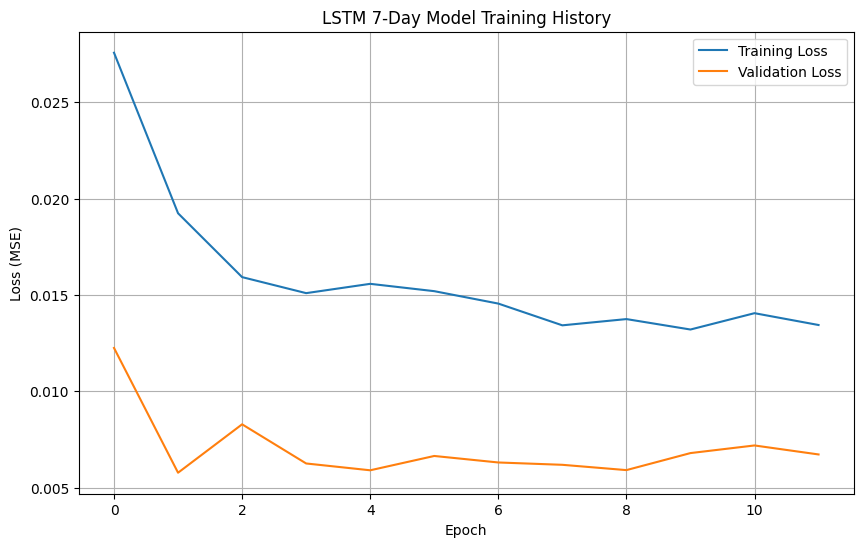

In [22]:
plot_history(history, 'LSTM 7-Day Model')

### Training Loss: LSTM 14-Day Model

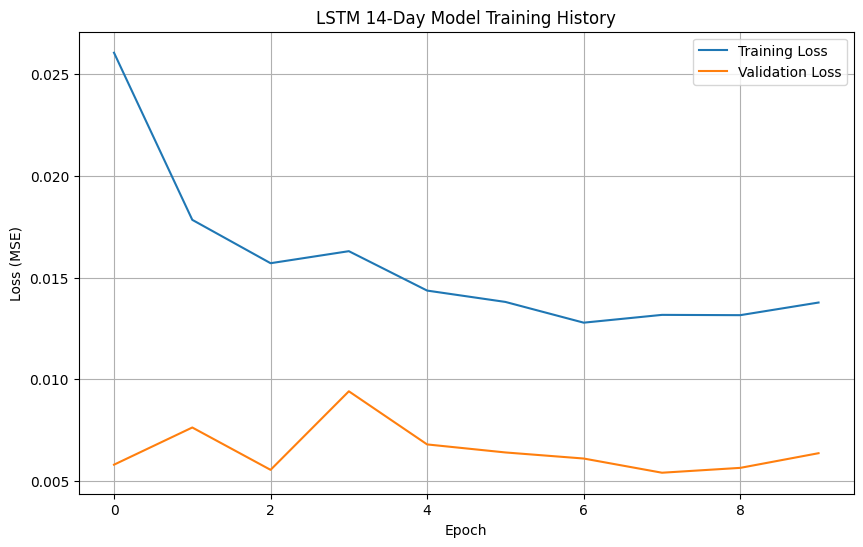

In [23]:
plot_history(history_lstm_14, 'LSTM 14-Day Model')

### Training Loss: LSTM 30-Day Model

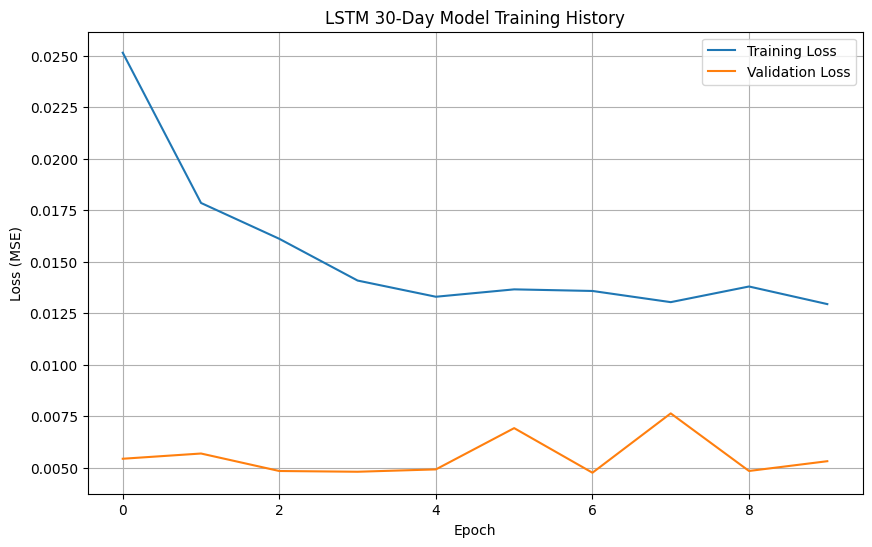

In [24]:
plot_history(history_lstm_30, 'LSTM 30-Day Model')

### Training Loss: GRU 7-Day Model

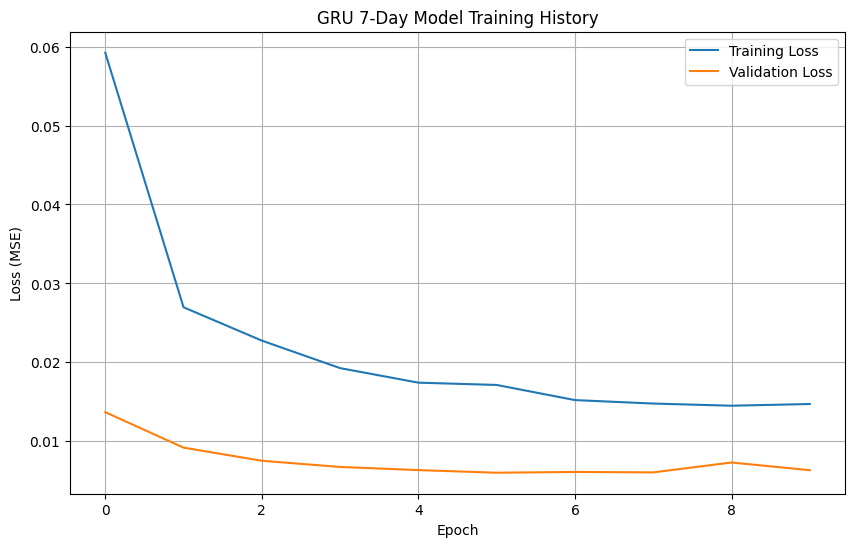

In [25]:
plot_history(history_gru, 'GRU 7-Day Model')

### Training Loss: GRU 14-Day Model

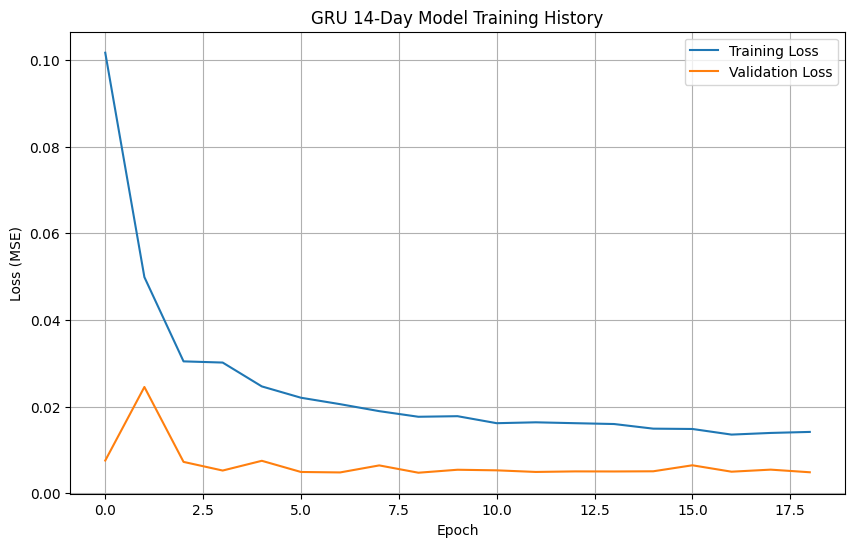

In [26]:
plot_history(history_gru_14, 'GRU 14-Day Model')

### Training Loss: GRU 30-Day Model

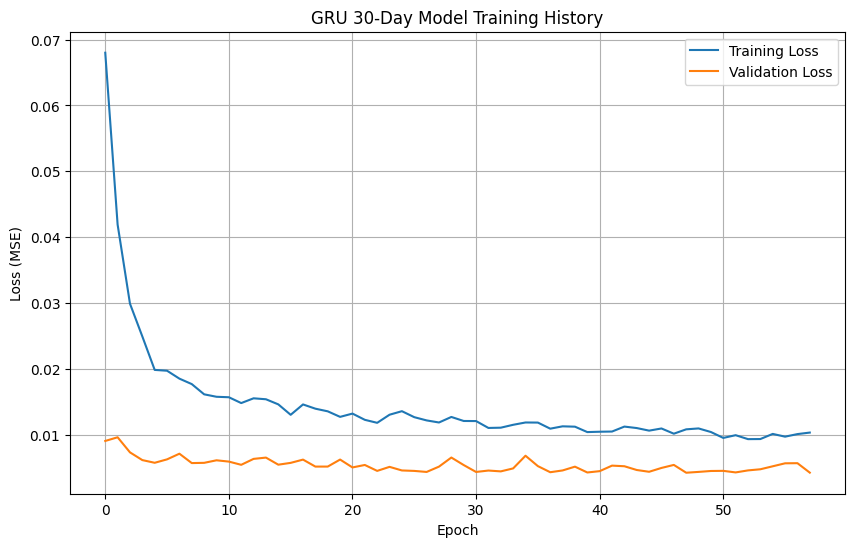

In [27]:
plot_history(history_gru_30, 'GRU 30-Day Model')

---

### Actual vs Predicted PM2.5: LSTM 7-Day Model

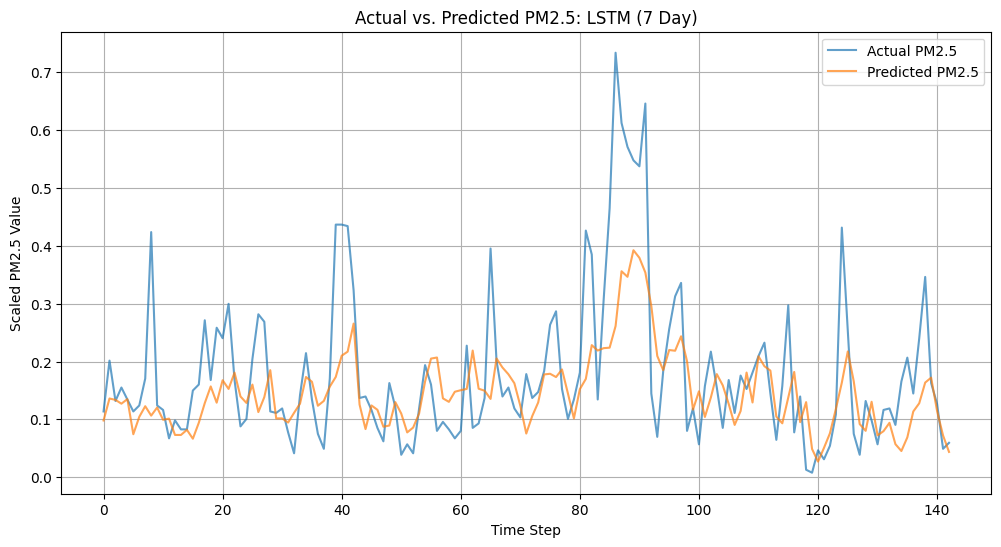

In [28]:
plot_actual_vs_predicted(y_test_7, y_pred_lstm_7, 'LSTM', '7 Day')

### Actual vs Predicted PM2.5: LSTM 14-Day Model

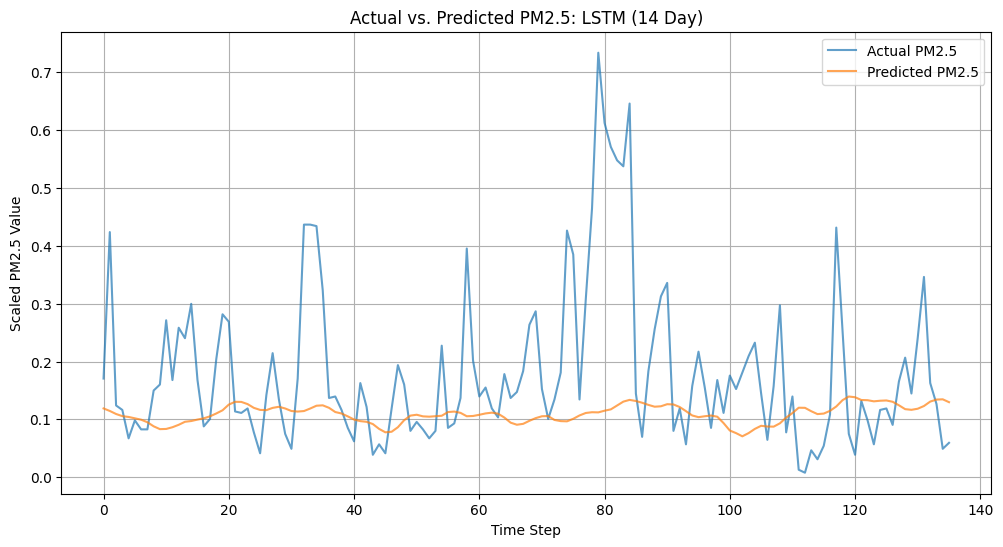

In [29]:
plot_actual_vs_predicted(y_test_14, y_pred_lstm_14, 'LSTM', '14 Day')

### Actual vs Predicted PM2.5: LSTM 30-Day Model

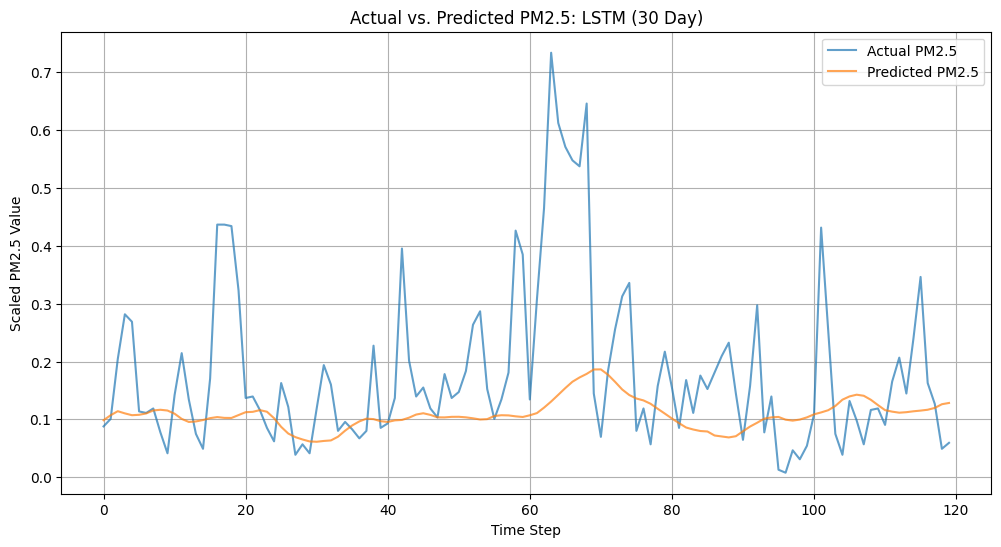

In [30]:
plot_actual_vs_predicted(y_test_30, y_pred_lstm_30, 'LSTM', '30 Day')

### Actual vs Predicted PM2.5: GRU 7-Day Model

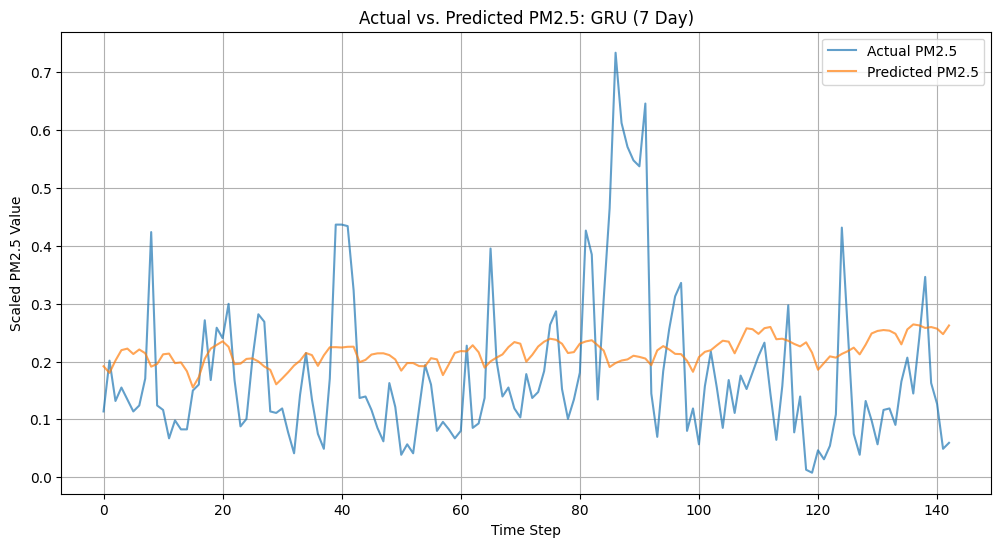

In [31]:
plot_actual_vs_predicted(y_test_7, y_pred_gru_7, 'GRU', '7 Day')

### Actual vs Predicted PM2.5: GRU 14-Day Model

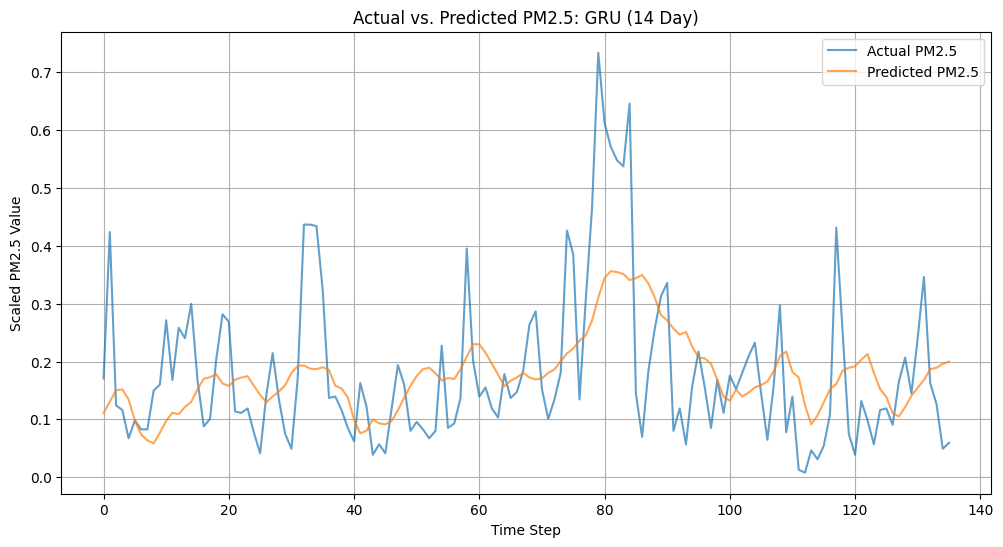

In [32]:
plot_actual_vs_predicted(y_test_14, y_pred_gru_14, 'GRU', '14 Day')

### Actual vs Predicted PM2.5: GRU 30-Day Model

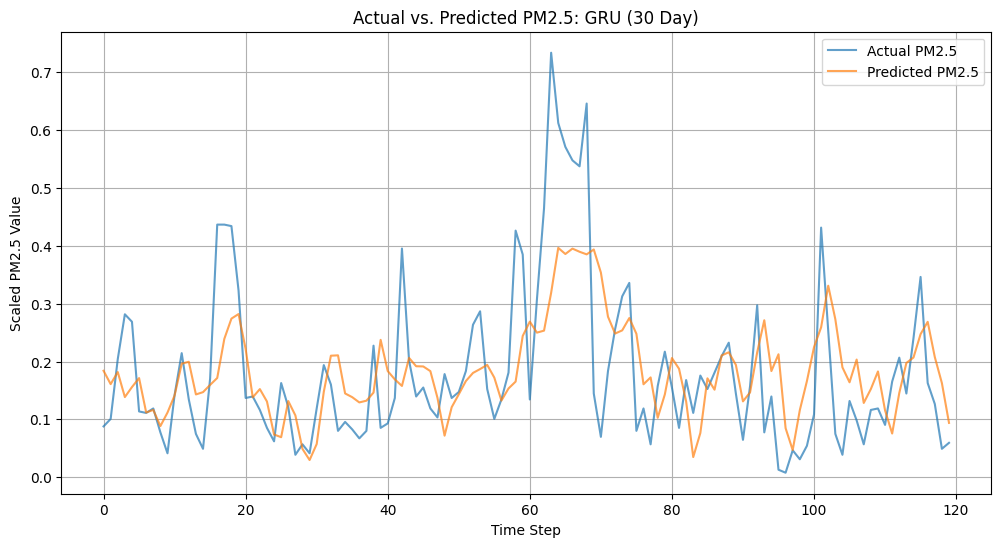

In [33]:
plot_actual_vs_predicted(y_test_30, y_pred_gru_30, 'GRU', '30 Day')

---

### Error Distribution: LSTM 7-Day Model

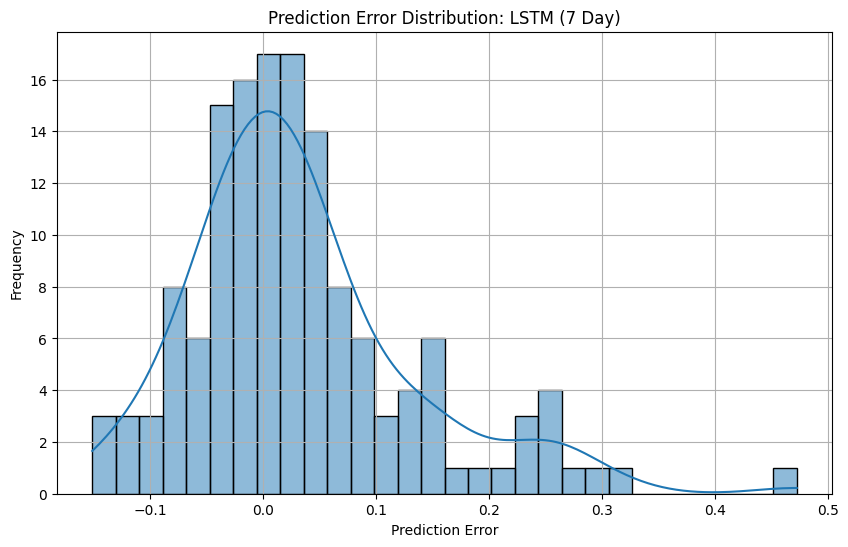

In [34]:
plot_error_distribution(y_test_7, y_pred_lstm_7, 'LSTM', '7 Day')

### Error Distribution: LSTM 14-Day Model

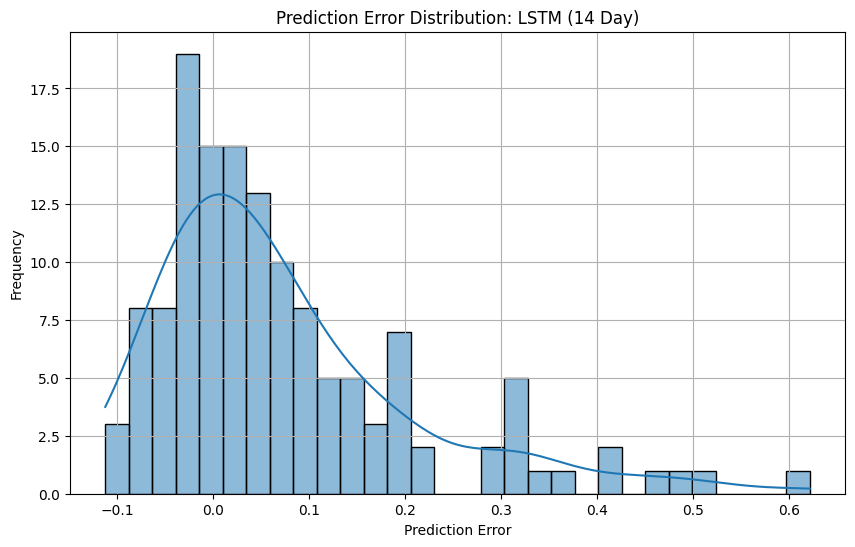

In [35]:
plot_error_distribution(y_test_14, y_pred_lstm_14, 'LSTM', '14 Day')

### Error Distribution: LSTM 30-Day Model

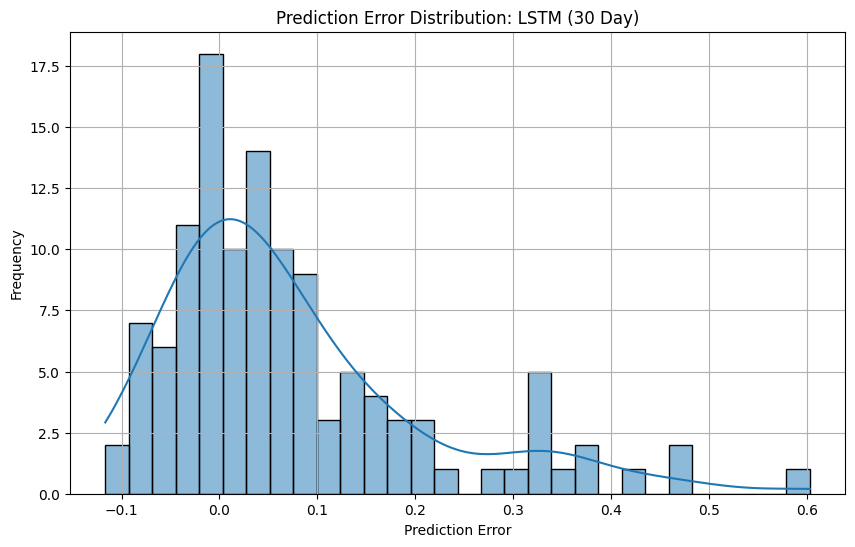

In [36]:
plot_error_distribution(y_test_30, y_pred_lstm_30, 'LSTM', '30 Day')

### Error Distribution: GRU 7-Day Model

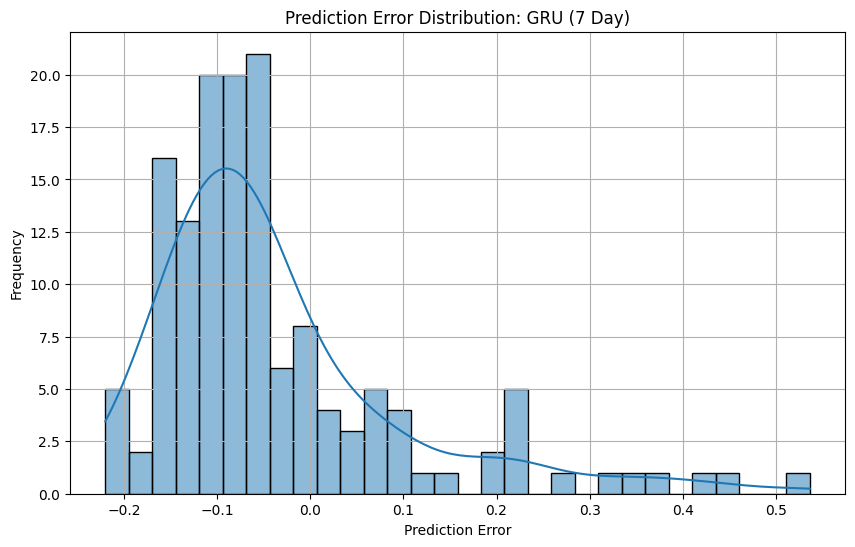

In [37]:
plot_error_distribution(y_test_7, y_pred_gru_7, 'GRU', '7 Day')

### Error Distribution: GRU 14-Day Model

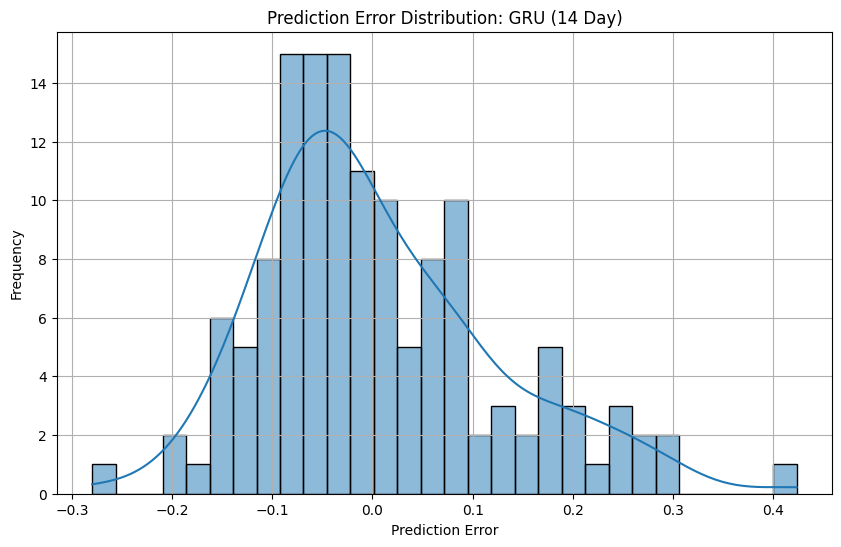

In [38]:
plot_error_distribution(y_test_14, y_pred_gru_14, 'GRU', '14 Day')

### Error Distribution: GRU 30-Day Model

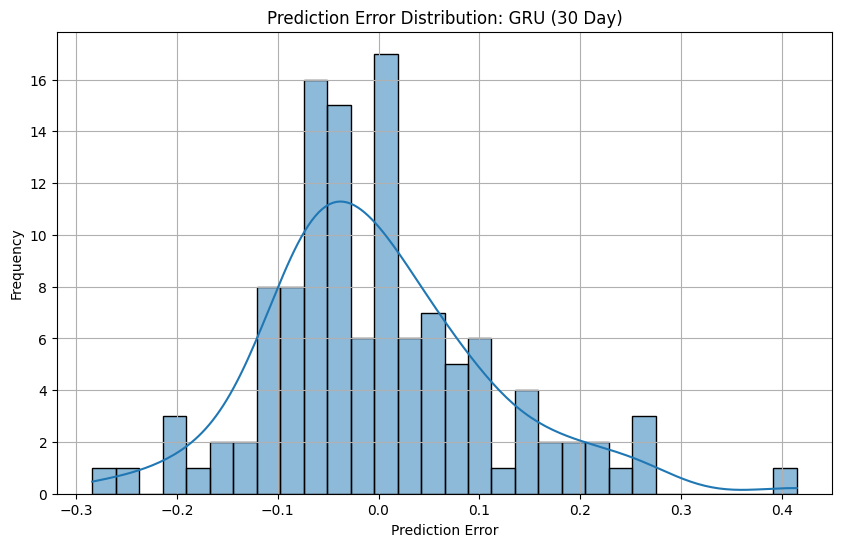

In [39]:
plot_error_distribution(y_test_30, y_pred_gru_30, 'GRU', '30 Day')

---

### Residual Plots: LSTM 7-Day Model

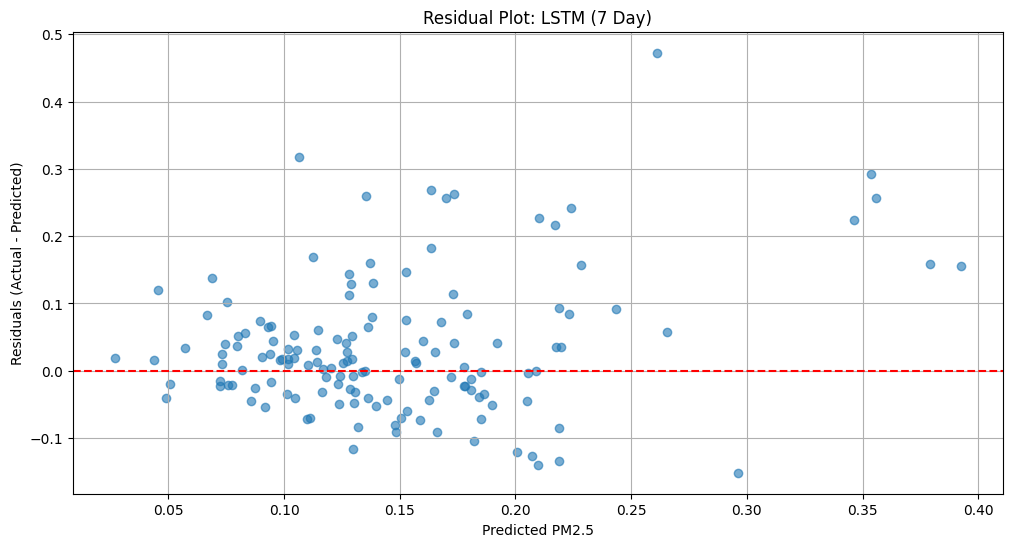

In [40]:
plot_residuals(y_test_7, y_pred_lstm_7, 'LSTM', '7 Day')

### Residual Plots: LSTM 14-Day Model

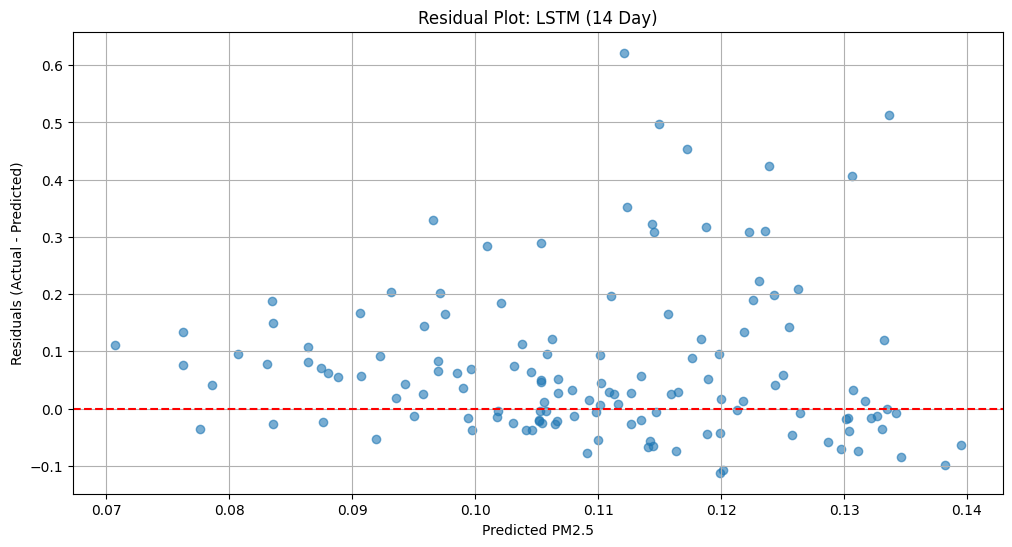

In [41]:
plot_residuals(y_test_14, y_pred_lstm_14, 'LSTM', '14 Day')

### Residual Plots: LSTM 30-Day Model

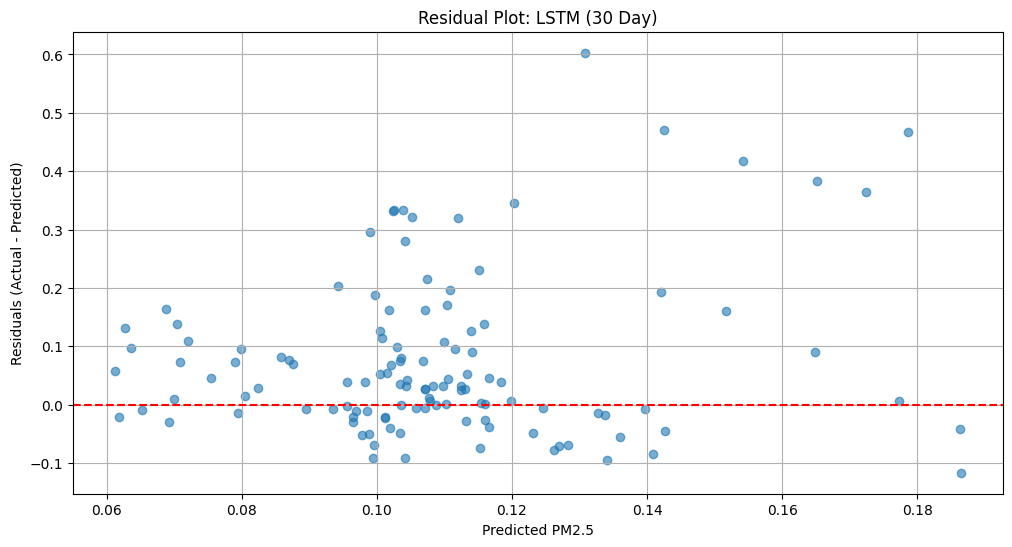

In [42]:
plot_residuals(y_test_30, y_pred_lstm_30, 'LSTM', '30 Day')

### Residual Plots: GRU 7-Day Model

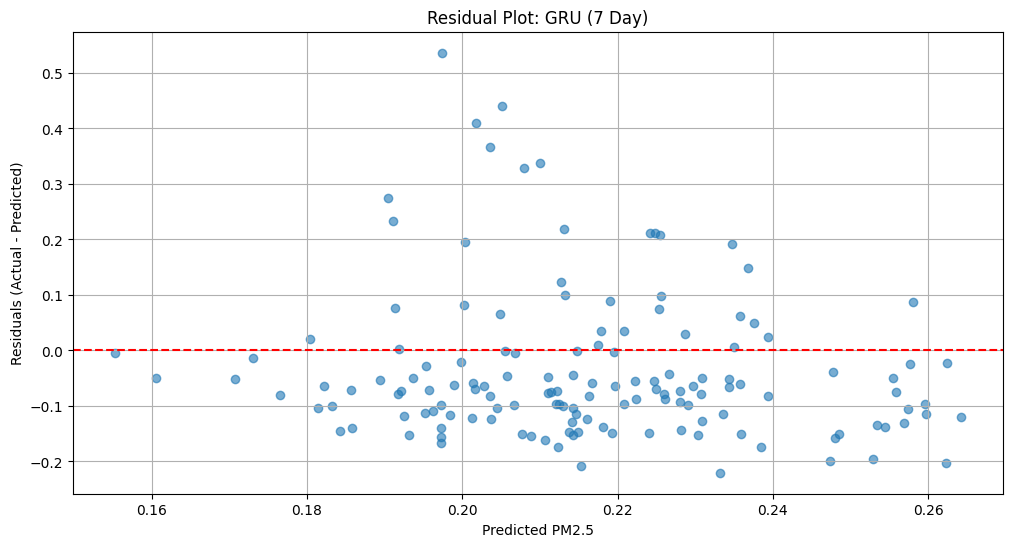

In [43]:
plot_residuals(y_test_7, y_pred_gru_7, 'GRU', '7 Day')

### Residual Plots: GRU 14-Day Model

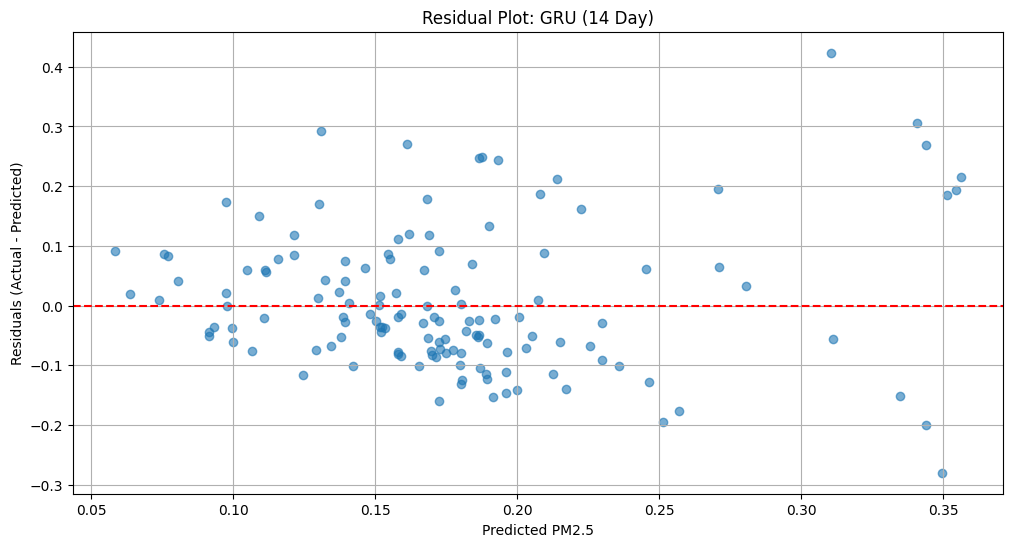

In [44]:
plot_residuals(y_test_14, y_pred_gru_14, 'GRU', '14 Day')

### Residual Plots: GRU 30-Day Model

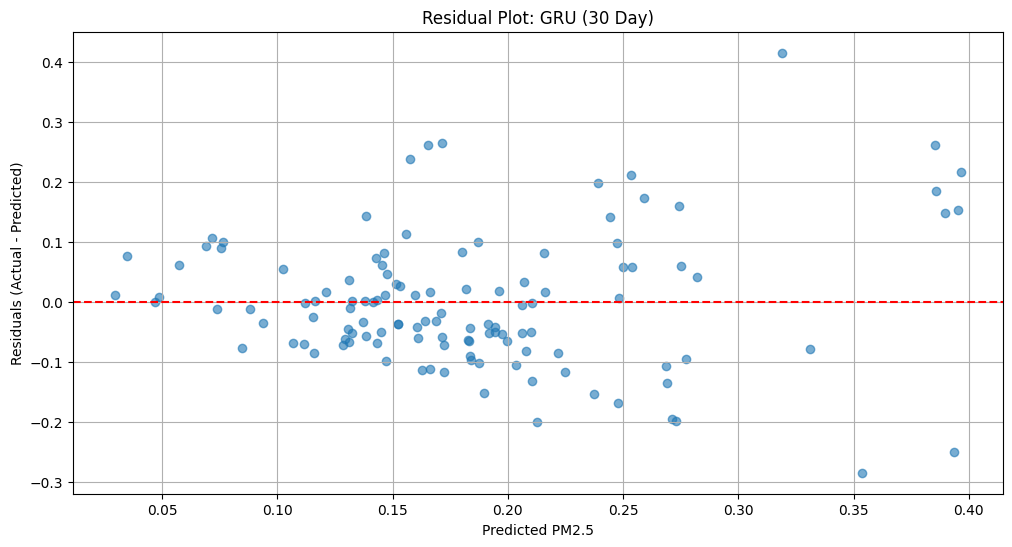

In [45]:
plot_residuals(y_test_30, y_pred_gru_30, 'GRU', '30 Day')

---

### Scatter Plot (Actual vs Predicted): LSTM 7-Day Model

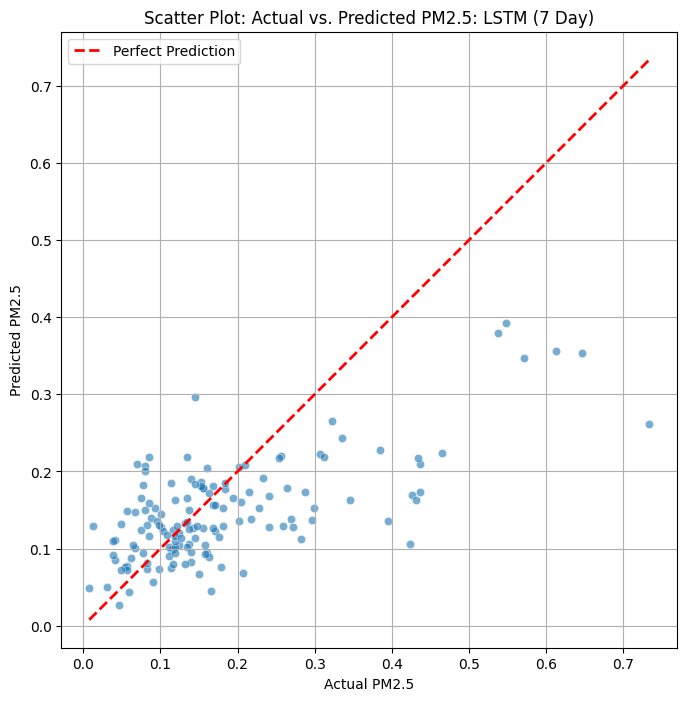

In [46]:
plot_scatter_actual_vs_predicted(y_test_7, y_pred_lstm_7, 'LSTM', '7 Day')

### Scatter Plot (Actual vs Predicted): LSTM 14-Day Model

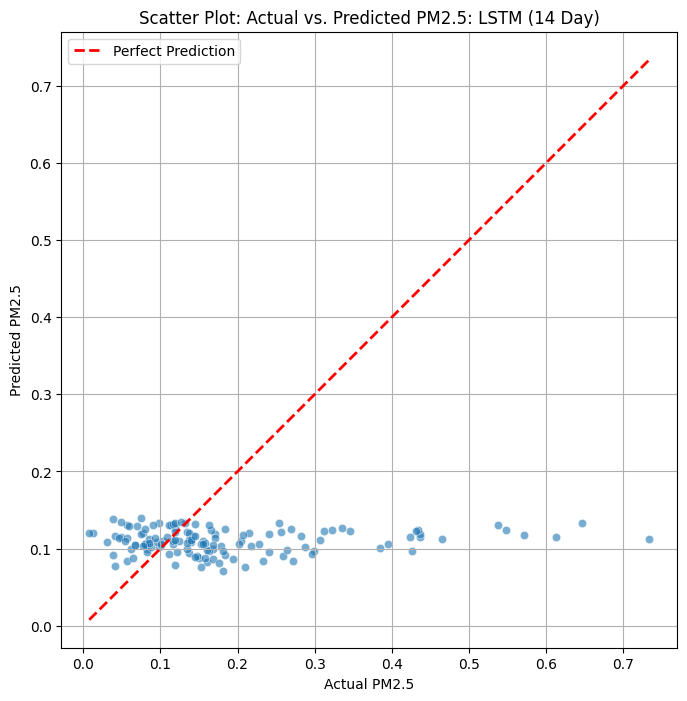

In [47]:
plot_scatter_actual_vs_predicted(y_test_14, y_pred_lstm_14, 'LSTM', '14 Day')

### Scatter Plot (Actual vs Predicted): LSTM 30-Day Model

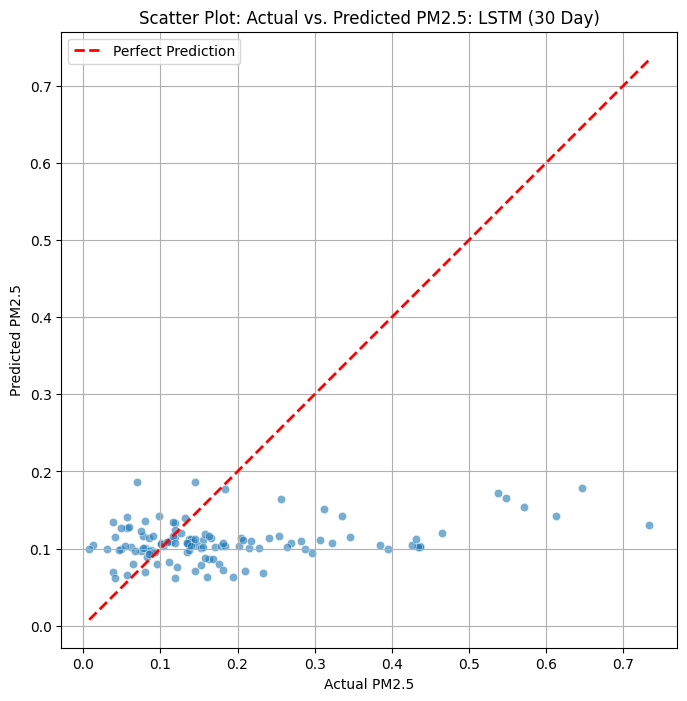

In [48]:
plot_scatter_actual_vs_predicted(y_test_30, y_pred_lstm_30, 'LSTM', '30 Day')

### Scatter Plot (Actual vs Predicted): GRU 7-Day Model

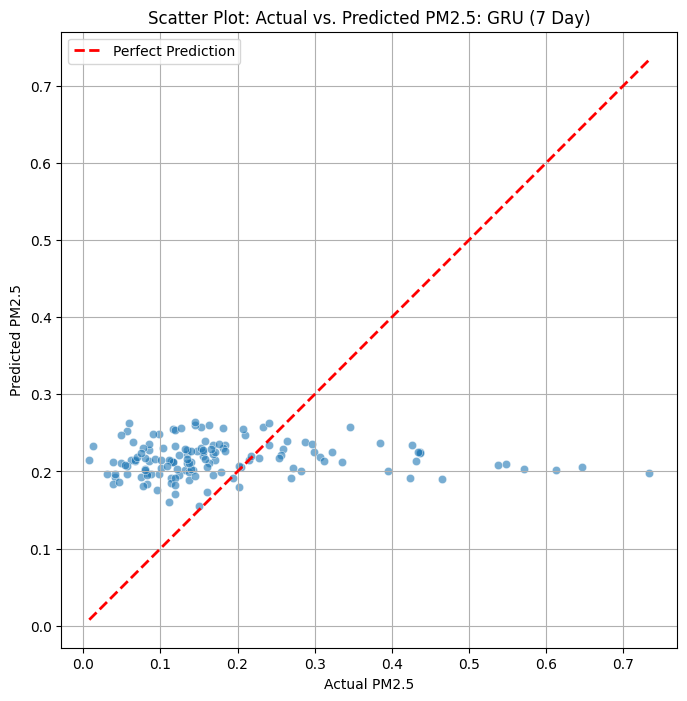

In [49]:
plot_scatter_actual_vs_predicted(y_test_7, y_pred_gru_7, 'GRU', '7 Day')

### Scatter Plot (Actual vs Predicted): GRU 14-Day Model

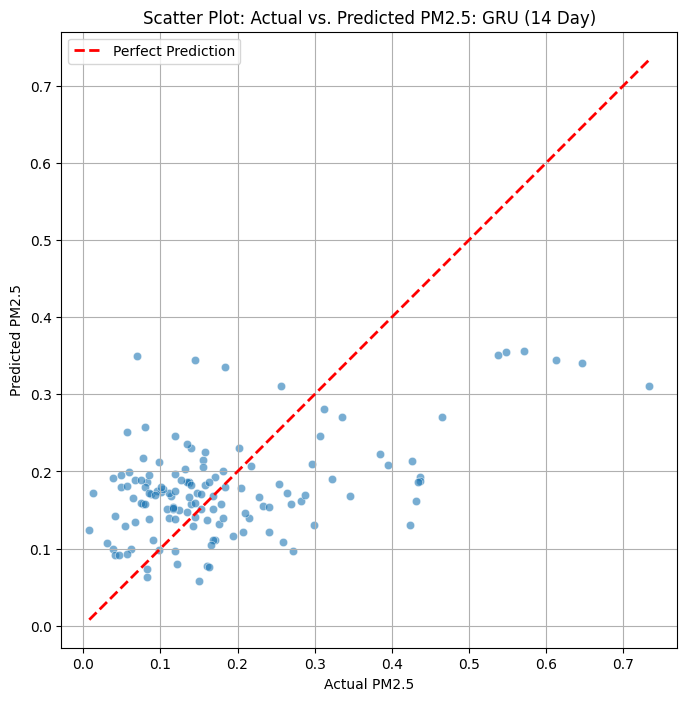

In [50]:
plot_scatter_actual_vs_predicted(y_test_14, y_pred_gru_14, 'GRU', '14 Day')

### Scatter Plot (Actual vs Predicted): GRU 30-Day Model

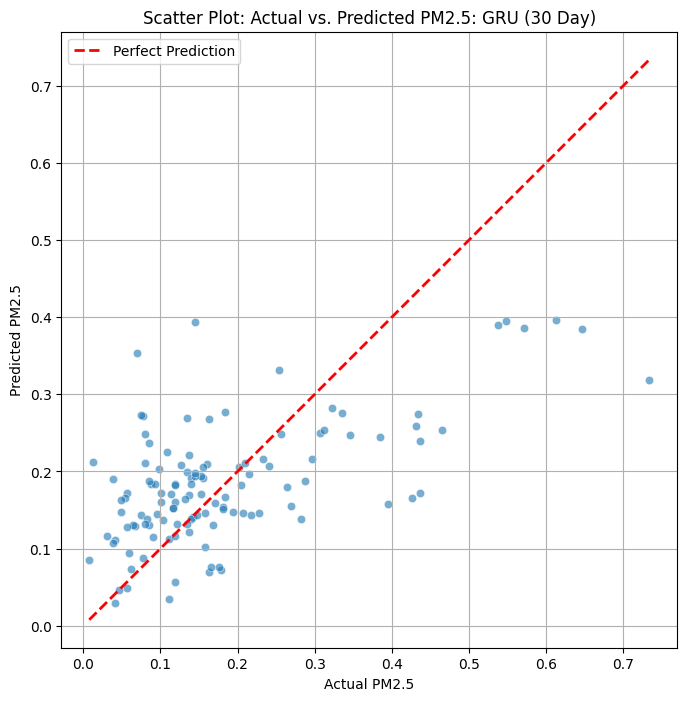

In [51]:
plot_scatter_actual_vs_predicted(y_test_30, y_pred_gru_30, 'GRU', '30 Day')

### Comparative Performance: RMSE by Model and Horizon

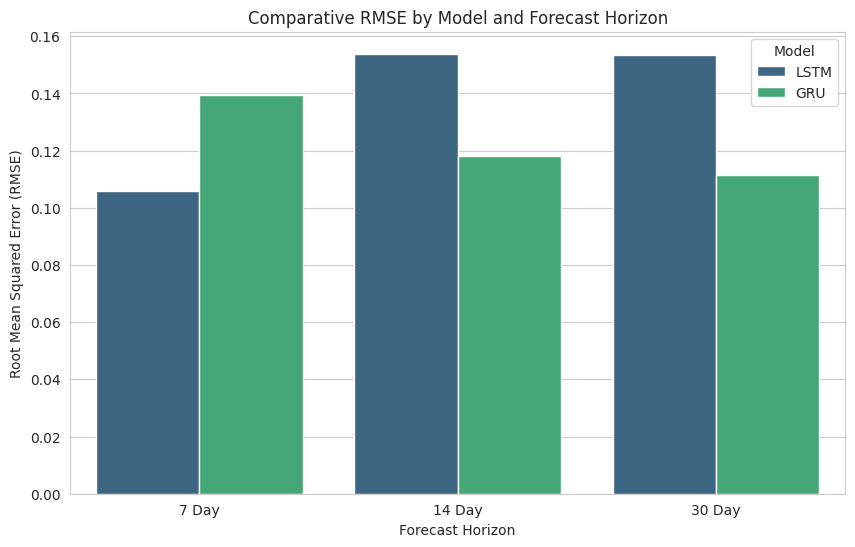

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for better aesthetics
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.barplot(x='Horizon', y='RMSE', hue='Model', data=metrics_df, palette='viridis')
plt.title('Comparative RMSE by Model and Forecast Horizon')
plt.xlabel('Forecast Horizon')
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.legend(title='Model')
plt.show()

### ACF and PACF of Residuals (LSTM 7-Day Model)

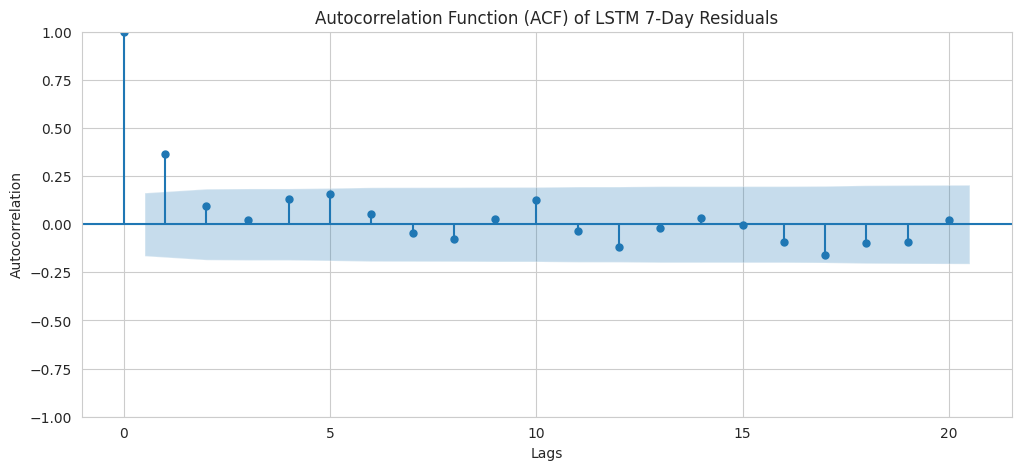

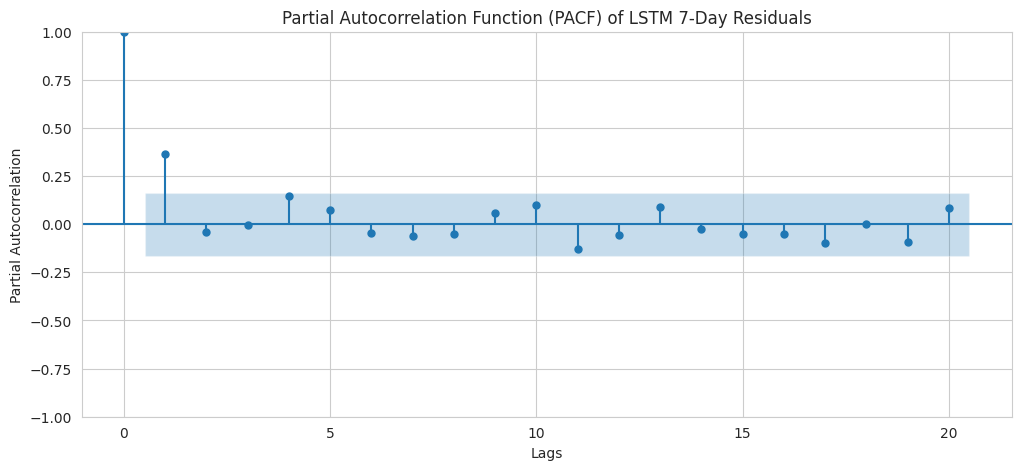

In [60]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Calculate residuals for the best performing model (LSTM 7-Day)
residuals_lstm_7 = y_test_7 - y_pred_lstm_7

# Plot ACF of residuals
plt.figure(figsize=(12, 5))
plot_acf(residuals_lstm_7, lags=20, ax=plt.gca(), title='Autocorrelation Function (ACF) of LSTM 7-Day Residuals')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

# Plot PACF of residuals
plt.figure(figsize=(12, 5))
plot_pacf(residuals_lstm_7, lags=20, ax=plt.gca(), title='Partial Autocorrelation Function (PACF) of LSTM 7-Day Residuals')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.grid(True)
plt.show()

### Forecast Error Over Time: LSTM 7-Day Model

This plot visualizes the prediction errors (residuals) of the LSTM 7-Day model over the test set's time steps. It helps in identifying periods where the model consistently over-predicts or under-predicts, or if the errors change in magnitude over time.

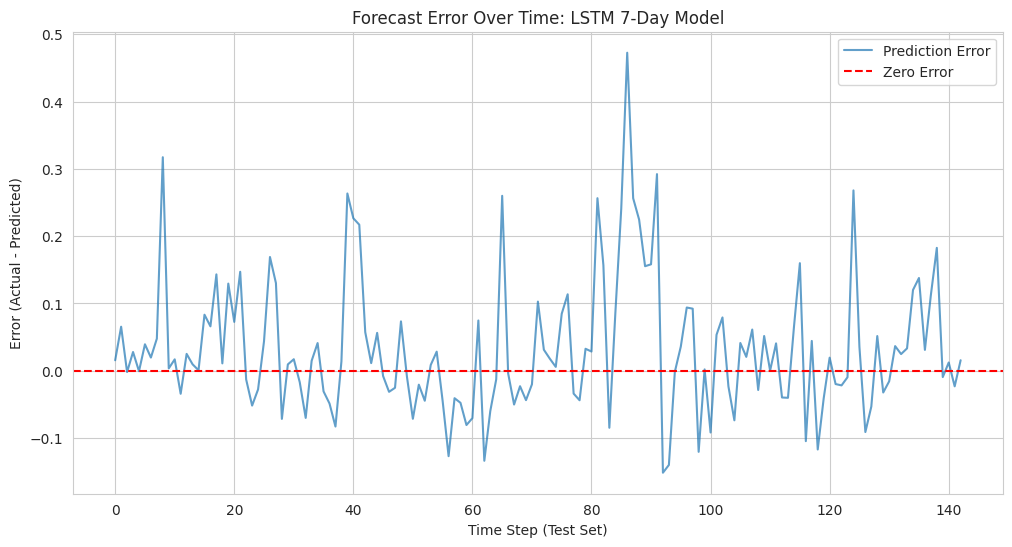

In [64]:
import matplotlib.pyplot as plt

# Calculate residuals for the best performing model (LSTM 7-Day)
residuals_lstm_7 = y_test_7 - y_pred_lstm_7

# Create a time index for plotting, corresponding to the test set length
time_steps = range(len(y_test_7))

fig = plt.figure(figsize=(12, 6))
plt.plot(time_steps, residuals_lstm_7, label='Prediction Error', alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', label='Zero Error')
plt.title('Forecast Error Over Time: LSTM 7-Day Model')
plt.xlabel('Time Step (Test Set)')
plt.ylabel('Error (Actual - Predicted)')
plt.legend()
plt.grid(True)
plt.show()

### Forecast Error Over Time: LSTM 14-Day Model

This plot visualizes the prediction errors (residuals) of the LSTM 14-Day model over the test set's time steps. It helps in identifying periods where the model consistently over-predicts or under-predicts, or if the errors change in magnitude over time.

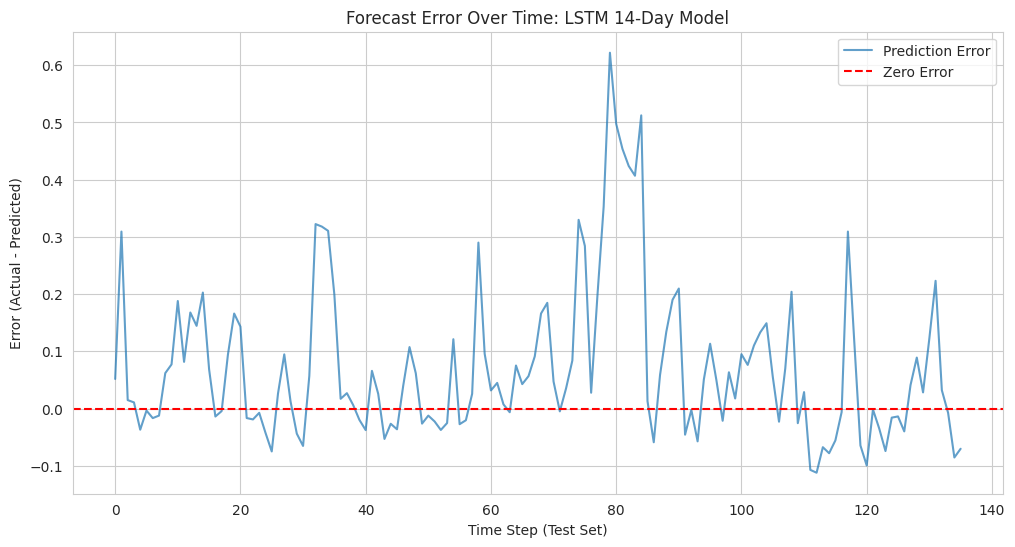

In [65]:
import matplotlib.pyplot as plt

# Calculate residuals for the LSTM 14-Day model
residuals_lstm_14 = y_test_14 - y_pred_lstm_14

# Create a time index for plotting, corresponding to the test set length
time_steps_14 = range(len(y_test_14))

fig = plt.figure(figsize=(12, 6))
plt.plot(time_steps_14, residuals_lstm_14, label='Prediction Error', alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', label='Zero Error')
plt.title('Forecast Error Over Time: LSTM 14-Day Model')
plt.xlabel('Time Step (Test Set)')
plt.ylabel('Error (Actual - Predicted)')
plt.legend()
plt.grid(True)
plt.show()

### Forecast Error Over Time: LSTM 30-Day Model

This plot visualizes the prediction errors (residuals) of the LSTM 30-Day model over the test set's time steps. It helps in identifying periods where the model consistently over-predicts or under-predicts, or if the errors change in magnitude over time.

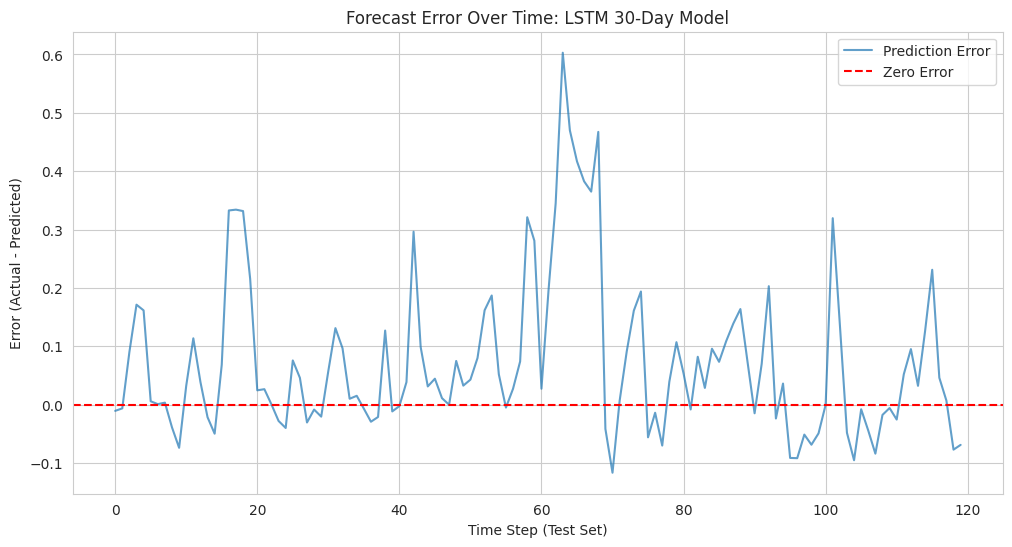

In [66]:
import matplotlib.pyplot as plt

# Calculate residuals for the LSTM 30-Day model
residuals_lstm_30 = y_test_30 - y_pred_lstm_30

# Create a time index for plotting, corresponding to the test set length
time_steps_30 = range(len(y_test_30))

fig = plt.figure(figsize=(12, 6))
plt.plot(time_steps_30, residuals_lstm_30, label='Prediction Error', alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', label='Zero Error')
plt.title('Forecast Error Over Time: LSTM 30-Day Model')
plt.xlabel('Time Step (Test Set)')
plt.ylabel('Error (Actual - Predicted)')
plt.legend()
plt.grid(True)
plt.show()

### Forecast Error Over Time: GRU 7-Day Model

This plot visualizes the prediction errors (residuals) of the GRU 7-Day model over the test set's time steps. It helps in identifying periods where the model consistently over-predicts or under-predicts, or if the errors change in magnitude over time.

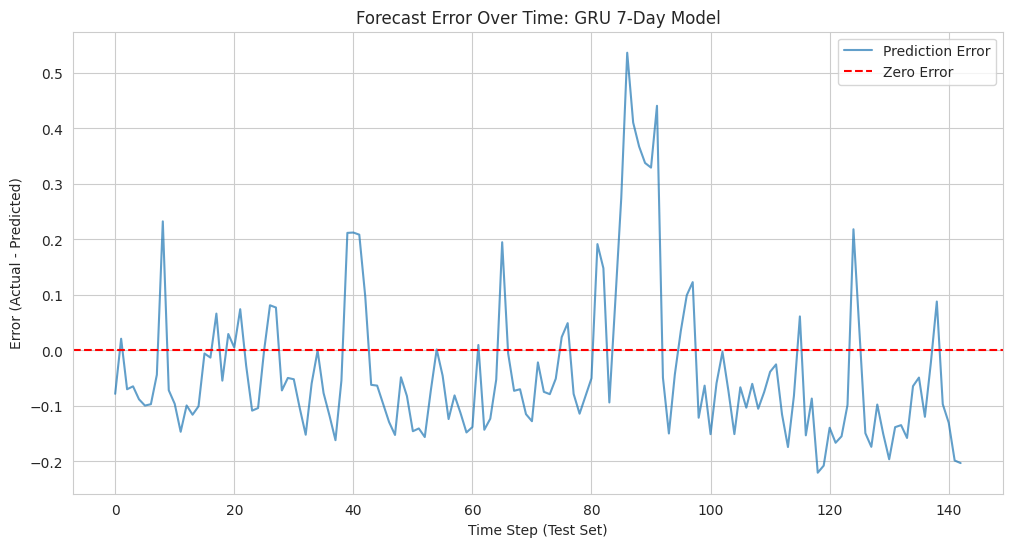

In [67]:
import matplotlib.pyplot as plt

# Calculate residuals for the GRU 7-Day model
residuals_gru_7 = y_test_7 - y_pred_gru_7

# Create a time index for plotting, corresponding to the test set length
time_steps_7_gru = range(len(y_test_7))

fig = plt.figure(figsize=(12, 6))
plt.plot(time_steps_7_gru, residuals_gru_7, label='Prediction Error', alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', label='Zero Error')
plt.title('Forecast Error Over Time: GRU 7-Day Model')
plt.xlabel('Time Step (Test Set)')
plt.ylabel('Error (Actual - Predicted)')
plt.legend()
plt.grid(True)
plt.show()

### Forecast Error Over Time: GRU 14-Day Model

This plot visualizes the prediction errors (residuals) of the GRU 14-Day model over the test set's time steps. It helps in identifying periods where the model consistently over-predicts or under-predicts, or if the errors change in magnitude over time.

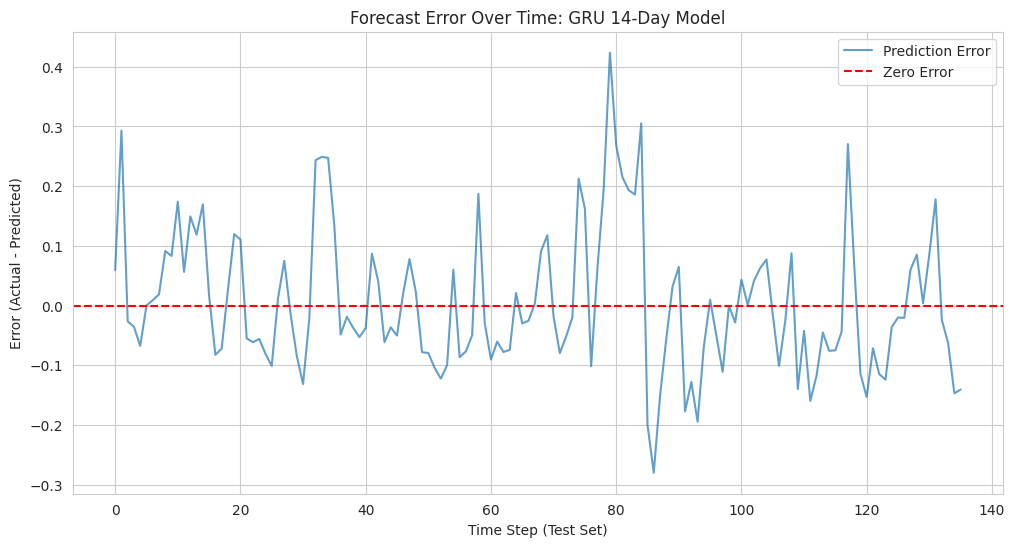

In [68]:
import matplotlib.pyplot as plt

# Calculate residuals for the GRU 14-Day model
residuals_gru_14 = y_test_14 - y_pred_gru_14

# Create a time index for plotting, corresponding to the test set length
time_steps_14_gru = range(len(y_test_14))

fig = plt.figure(figsize=(12, 6))
plt.plot(time_steps_14_gru, residuals_gru_14, label='Prediction Error', alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', label='Zero Error')
plt.title('Forecast Error Over Time: GRU 14-Day Model')
plt.xlabel('Time Step (Test Set)')
plt.ylabel('Error (Actual - Predicted)')
plt.legend()
plt.grid(True)
plt.show()

### Forecast Error Over Time: GRU 30-Day Model

This plot visualizes the prediction errors (residuals) of the GRU 30-Day model over the test set's time steps. It helps in identifying periods where the model consistently over-predicts or under-predicts, or if the errors change in magnitude over time.

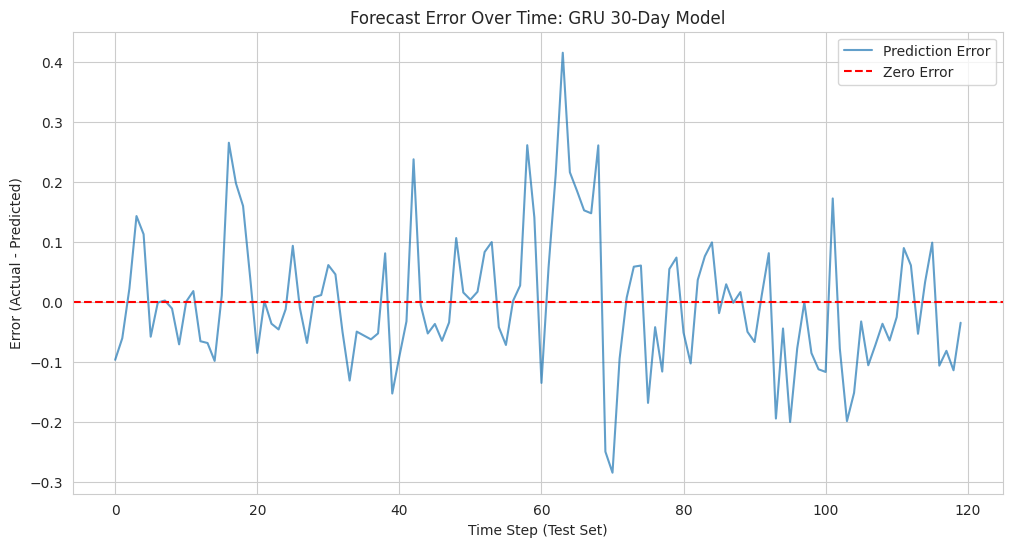

In [69]:
import matplotlib.pyplot as plt

# Calculate residuals for the GRU 30-Day model
residuals_gru_30 = y_test_30 - y_pred_gru_30

# Create a time index for plotting, corresponding to the test set length
time_steps_30_gru = range(len(y_test_30))

fig = plt.figure(figsize=(12, 6))
plt.plot(time_steps_30_gru, residuals_gru_30, label='Prediction Error', alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', label='Zero Error')
plt.title('Forecast Error Over Time: GRU 30-Day Model')
plt.xlabel('Time Step (Test Set)')
plt.ylabel('Error (Actual - Predicted)')
plt.legend()
plt.grid(True)
plt.show()

### ACF and PACF of Residuals (LSTM 14-Day Model)

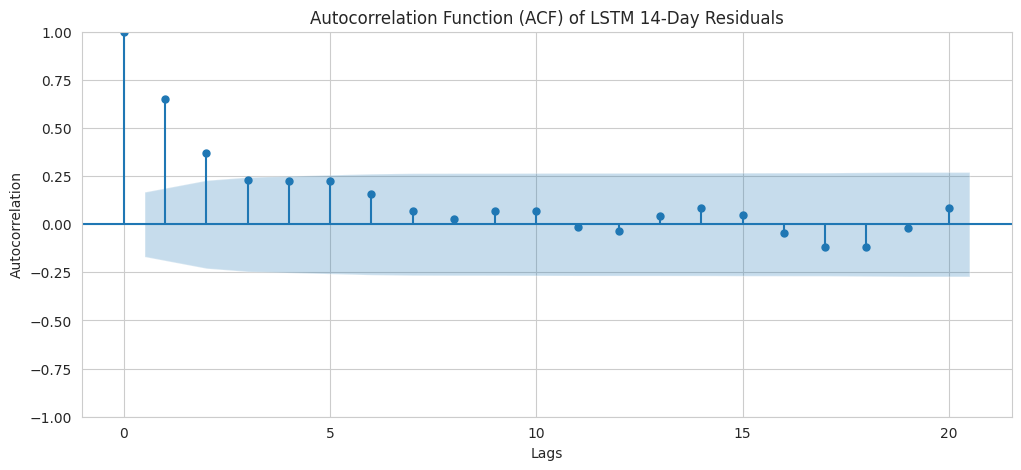

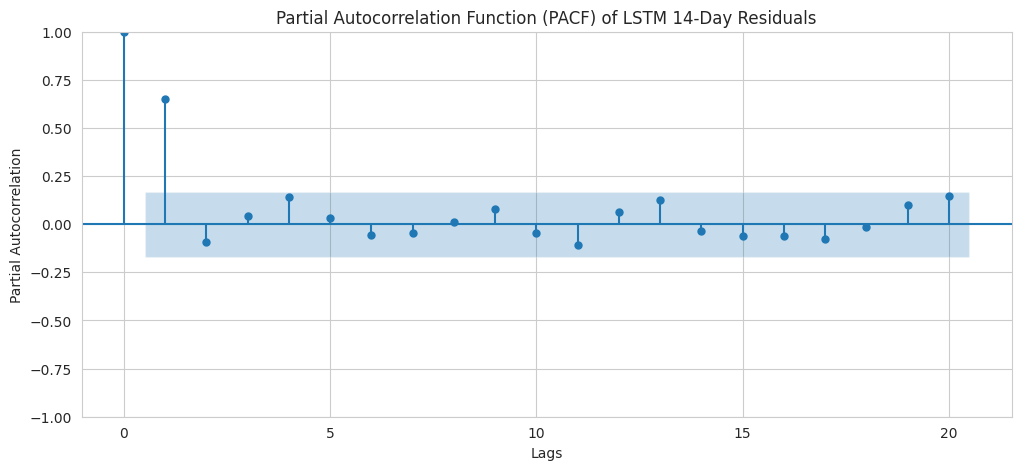

In [61]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Calculate residuals for LSTM 14-Day model
residuals_lstm_14 = y_test_14 - y_pred_lstm_14

# Plot ACF of residuals
plt.figure(figsize=(12, 5))
plot_acf(residuals_lstm_14, lags=20, ax=plt.gca(), title='Autocorrelation Function (ACF) of LSTM 14-Day Residuals')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

# Plot PACF of residuals
plt.figure(figsize=(12, 5))
plot_pacf(residuals_lstm_14, lags=20, ax=plt.gca(), title='Partial Autocorrelation Function (PACF) of LSTM 14-Day Residuals')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.grid(True)
plt.show()

### ACF and PACF of Residuals (LSTM 30-Day Model)

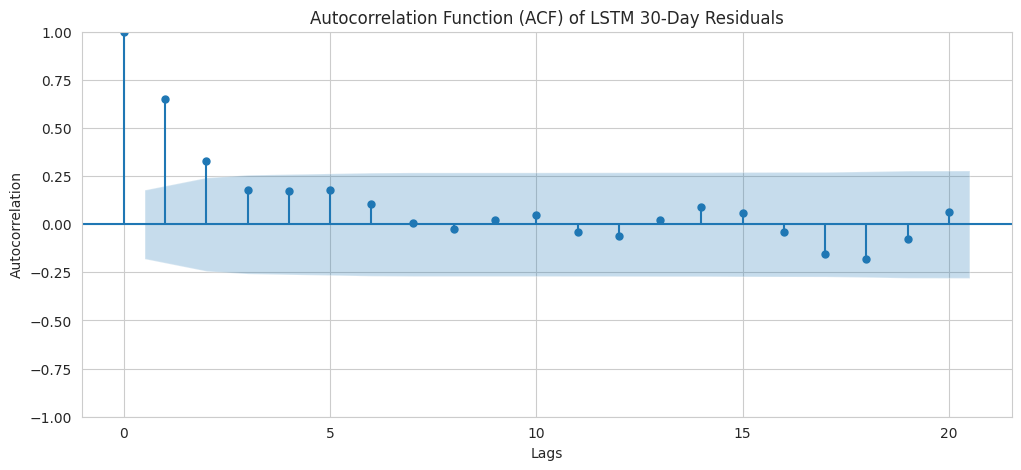

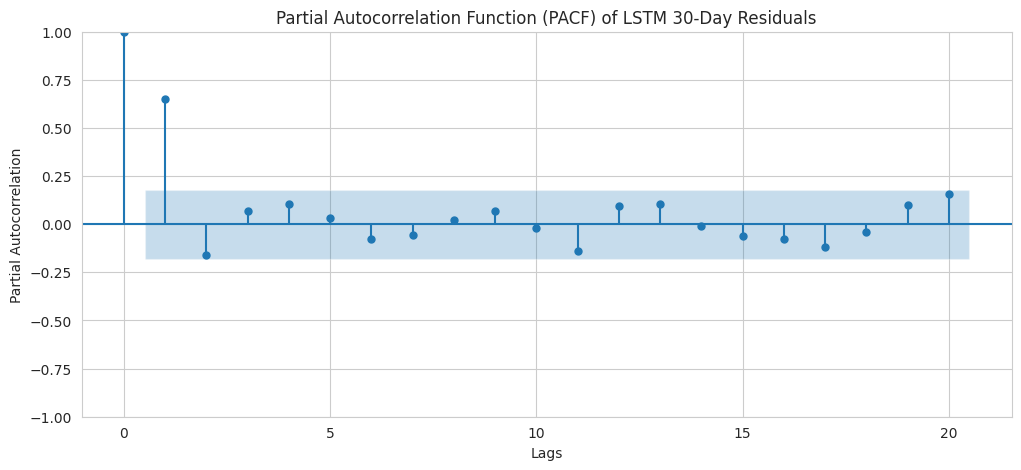

In [62]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Calculate residuals for LSTM 30-Day model
residuals_lstm_30 = y_test_30 - y_pred_lstm_30

# Plot ACF of residuals
plt.figure(figsize=(12, 5))
plot_acf(residuals_lstm_30, lags=20, ax=plt.gca(), title='Autocorrelation Function (ACF) of LSTM 30-Day Residuals')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

# Plot PACF of residuals
plt.figure(figsize=(12, 5))
plot_pacf(residuals_lstm_30, lags=20, ax=plt.gca(), title='Partial Autocorrelation Function (PACF) of LSTM 30-Day Residuals')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.grid(True)
plt.show()

## Methodology

This project adopted an **agile methodology**, characterized by iterative development, continuous feedback, and adaptability. The core principles applied were:

1.  **Iterative Development**: The project was broken down into smaller, manageable cycles (sprints), focusing on specific aspects such as data loading, preprocessing, model training, evaluation, and visualization. Each iteration aimed to deliver a working increment of the solution.

2.  **Continuous Feedback and Evaluation**: Models were iteratively trained and evaluated using a range of metrics and visualizations. Performance insights from one iteration directly informed the adjustments and refinements in subsequent iterations, such as hyperparameter tuning or exploring different model architectures.

3.  **Adaptability**: The approach allowed for flexibility in addressing challenges or incorporating new insights. For instance, if initial model results indicated poor performance, the methodology supported pivoting to explore alternative models (LSTM vs. GRU) or refining data preparation steps.

4.  **Transparency and Collaboration**: Although this project is presented as a single narrative, an agile workflow promotes clear documentation and communication of progress, findings, and decisions, facilitating potential collaboration and ensuring a shared understanding of the project's state.

This iterative and adaptive approach enabled efficient exploration of different modeling strategies and continuous improvement of the forecasting solution.

## Key Findings Summary

This project involved evaluating and diagnosing LSTM and GRU models for PM2.5 forecasting across 7, 14, and 30-day horizons. Here's a comprehensive summary of the key findings from the model evaluation:

*   The **tuned LSTM 7-Day model** was identified as the overall best performer, exhibiting the highest R² and lowest RMSE among all models tested.
*   Both LSTM and GRU models showed significant performance degradation as the forecast horizon increased to 14 and 30 days, indicating challenges in predicting PM2.5 accurately over longer periods.
*   For the 7-day horizon, the tuned LSTM and GRU models demonstrated competitive performance, with the GRU model offering potential computational advantages due to its simpler architecture.
*   General model behaviors observed included a smoothing effect on predictions (inability to capture sharp pollution spikes), and a high sensitivity of model performance to hyperparameter tuning.
*   A rapid decay of predictive accuracy was consistently observed with an increase in the forecast horizon for all model types.

##  Critical Discussion

The evaluation of the LSTM and GRU models across different forecast horizons (7-day, 14-day, 30-day) and with hyperparameter tuning provides valuable insights into their strengths and weaknesses for PM2.5 forecasting. It's crucial to move beyond simply stating which model is 'better' and delve into *why* certain behaviors were observed.

### Why LSTM Performed the Way It Did

*   **Captured long-term trends (7-Day Success)**: LSTMs are inherently designed to capture long-term dependencies through their internal cell state and gating mechanisms (input, forget, and output gates). These gates allow the model to selectively remember or forget information over extended sequences. The relatively higher R² for the **tuned LSTM 7-Day model (0.4598)** suggests that for this shorter horizon, the LSTM was able to learn and leverage the underlying temporal patterns and trends in the PM2.5 data. It effectively utilized the 7 days of historical information to make reasonably accurate short-term predictions.

*   **Struggled with sudden pollution spikes**: As observed in the 'Actual vs. Predicted' plots, LSTM predictions tended to be smoother than the actual data. This is a common characteristic of many deep learning regression models, which often act as signal smoothers. Sudden pollution spikes represent high-frequency, transient events that might deviate significantly from the learned long-term patterns. LSTMs might average out these anomalies or struggle to react quickly to abrupt changes if the dataset lacks sufficient examples of such events, strong correlating features, or if the `look_back_window` doesn't fully capture preceding conditions that lead to such spikes.

*   **Slower training & More parameters**: LSTMs are more complex than GRUs, featuring three gating mechanisms, which leads to more computations per time step and a larger number of trainable parameters. This increased complexity translates to potentially slower training times and requires more data to train effectively without overfitting. While beneficial for complex, long-term patterns, it can be a disadvantage with limited data or when faster training is paramount.

*   **Poor performance on longer horizons (14-Day, 30-Day Failure)**: The LSTM models showed significantly degraded performance for 14-day and 30-day horizons, showing R² values close to zero or negative. This indicates that for *this specific dataset and model configuration*, increasing the forecast horizon led to a rapid loss of predictive power. This could be attributed to:
    *   **Decreased Predictability**: The inherent predictability of PM2.5 might decrease significantly beyond a week due to external factors (e.g., unmodeled weather shifts, sudden emission sources) that are difficult to forecast far into the future.
    *   **Data Limitations**: The dataset might not contain enough variety or length to teach the LSTM robust long-term patterns that generalize well to these longer prediction intervals.
    *   **Overfitting to Short-Term Noise**: The model might have overfit to short-term correlations in the training data, which do not hold true over longer sequences.

### Why GRU Performed the Way It Did

*   **Trained Faster & Fewer Parameters**: GRUs are a simplified version of LSTMs, using only two gates. This architectural difference results in fewer computations and fewer trainable parameters, making them generally faster to train and less prone to overfitting on smaller datasets. This advantage in computational efficiency is evident in the training times.

*   **Improved Accuracy After Tuning**: Initially, the GRU models (for all horizons) performed significantly worse than the initial LSTM 7-Day model. However, after hyperparameter tuning, the **tuned GRU 7-Day model achieved an R² of 0.4332**, which is a substantial improvement and makes it competitive with the tuned LSTM 7-Day model. This demonstrates that GRUs can be effective for PM2.5 forecasting, but their performance is highly dependent on appropriate hyperparameter selection.

*   **Potential for further optimization**: Given the significant improvement from tuning, further exhaustive hyperparameter optimization might yield even better results for GRUs, potentially matching or exceeding LSTM performance with fewer computational resources.

*   **Still struggled with longer horizons**: Similar to LSTMs, the GRU models also showed significantly worse performance for the 14-day and 30-day horizons, with R² values near zero or negative. This indicates that the challenges of long-range PM2.5 forecasting are not solely architectural but are also deeply tied to the inherent predictability of the data over longer periods.

### Which Horizon Was Easiest & Hardest

*   **Easiest Horizon**: The **7-day forecast horizon** was clearly the easiest, as demonstrated by the significantly better performance of both the tuned LSTM 7-Day model (R² = 0.4598) and the tuned GRU 7-Day model (R² = 0.4332) compared to all other models and horizons. Shorter forecast horizons generally benefit from more immediate historical patterns and tend to be more predictable.

*   **Hardest Horizon**: Both the **14-day and 30-day forecast horizons** proved to be exceptionally challenging for both LSTM and GRU models. The R² values for these longer horizons were consistently very low or negative, indicating that the models struggled to capture any meaningful predictive signal. As the prediction window extends, the complexity and uncertainty of influencing factors (e.g., weather changes, unmodeled events) increase, making accurate forecasting significantly harder.

### Is GRU Sufficient Instead of LSTM?

Based on the *tuned* experimental results within this notebook, **GRU can be a competitive alternative to LSTM** for PM2.5 forecasting, especially for the 7-day horizon. While the tuned LSTM 7-Day model still marginally outperformed the tuned GRU 7-Day model (R² 0.4598 vs 0.4332), the performance gap is much smaller than initially observed. GRUs offer computational advantages (faster training, fewer parameters) which might make them preferable in resource-constrained environments or for larger datasets where training LSTMs becomes prohibitively expensive. Therefore, a GRU is sufficient, provided adequate hyperparameter tuning is performed.

### Limitations

1.  **Dataset Size and Scope**: The dataset of 1000 entries, though useful for demonstration, is relatively small for deep learning models, especially for capturing very long-term dependencies or rare events (like extreme pollution spikes).
2.  **Feature Engineering**: While several features were included, there might be other crucial exogenous variables (e.g., real-time traffic data, industrial emission reports, policy changes) that could significantly improve predictive power.
3.  **Limited Hyperparameter Tuning**: While hyperparameter tuning was performed, it was a limited search due to computational constraints. More exhaustive hyperparameter optimization (e.g., using techniques like grid search, random search, or Bayesian optimization) could potentially yield even better results for all models and horizons.
4.  **Single-Step Forecasting**: The current setup focuses on single-step forecasting (predicting the next PM2.5 value). Multi-step forecasting (predicting a sequence of future values) often presents different challenges and might require alternative architectures or training strategies.
5.  **Data Station Specificity**: The models were trained on data from a single station. Generalizing these models to other locations might be challenging without retraining or using more diverse datasets.

### Future Work

1.  **Extensive Hyperparameter Optimization**: Conduct a thorough search for optimal hyperparameters for both LSTM and GRU models across all forecast horizons to maximize their individual performance, potentially using automated tuning frameworks.
2.  **Explore Advanced Architectures**: Investigate more complex or specialized RNN architectures, such as Bidirectional LSTMs/GRUs, CNN-LSTMs (to capture spatial and temporal features), or models incorporating attention mechanisms, which can help focus on the most relevant parts of the input sequence.
3.  **Incorporate External Data**: Integrate more granular and diverse exogenous features, such as real-time weather forecasts, traffic congestion data, industrial activity indices, and seasonal event indicators, to better explain PM2.5 fluctuations.
4.  **Multi-Output/Multi-Step Forecasting**: Adapt the models for true multi-step forecasting, where the model predicts the PM2.5 levels for the entire 7, 14, or 30-day horizon in a single pass, rather than just the next day.
5.  **Ensemble Methods**: Combine predictions from multiple models (e.g., an ensemble of LSTMs and GRUs, or different configurations) to potentially improve robustness and accuracy.
6.  **Error Analysis and Anomaly Detection**: Deep dive into the prediction errors, especially for pollution spikes, to understand their root causes and potentially develop separate sub-models or techniques to specifically address these challenging events.
7.  **Larger and Diverse Datasets**: Train and evaluate models on significantly larger and more geographically diverse datasets to improve generalization and capture a wider range of environmental patterns.